In [1]:
!rm metadata_.json
!rm metadata_2.json

rm: cannot remove 'metadata_.json': No such file or directory
rm: cannot remove 'metadata_2.json': No such file or directory


In [2]:
import pandas as pd
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier

my_df = pd.read_csv("/kaggle/input/datasets/luca23434/adult-data-census/adult-data-census.csv",index_col=0)

In [3]:
df_reset = my_df.reset_index()


In [4]:
import numpy as np
df_reset = df_reset.replace('^ ', '', regex=True)
df_reset = df_reset.replace('?', np.nan)


In [5]:
null_values = df_reset.isnull().sum(axis=1)
for i in range(3):
    null_values = list(filter(lambda x: x > i, null_values))
    


In [6]:
df_reset.columns = list(map(lambda x: x.replace(" ", ""), df_reset.columns))

In [7]:
df_reset.columns = list(map(lambda x: x.replace("-", "_"), df_reset.columns))

In [8]:
df_reset_copy = df_reset.dropna()

In [9]:
columns_values = df_reset_copy.columns

In [10]:
is_col_continuos = []
is_col_categorical = []
is_col_categorical_many_examples = []
is_col_discrete = []
is_col_ordinal = []
import math

for elements_cols in df_reset_copy.columns:
    give_exception = False
    if ".float" in str(type(df_reset_copy.at[0, elements_cols])):
        give_exception = True
        for idx in range(len(df_reset_copy[elements_cols])):
            if 'float' in str(type(df_reset_copy.loc[idx, elements_cols])) and math.isnan(df_reset_copy.loc[idx, elements_cols]):
                continue
            give_exception = df_reset_copy.loc[idx, elements_cols] == float(int(df_reset_copy.loc[idx, elements_cols]))
            if give_exception == False:
                break
        if give_exception and df_reset_copy[elements_cols].nunique() < 20:
            is_col_categorical.append(elements_cols)
        elif give_exception and df_reset_copy[elements_cols].nunique() < 50:
            is_col_categorical_many_examples.append(elements_cols)
        else:
            is_col_continuos.append(elements_cols)
    
    elif df_reset_copy[elements_cols].nunique() < 20:
        is_col_categorical.append(elements_cols)
    elif df_reset_copy[elements_cols].nunique() < 50:
        is_col_categorical_many_examples.append(elements_cols)
    elif ".int" in str(type(df_reset_copy.at[0, elements_cols])):
        is_col_discrete.append(elements_cols)
    else:
        is_col_ordinal.append(elements_cols)


In [11]:
df_reset_copy_ = df_reset.copy()

Here we try to reduce the number of unique values from categorical columns, we will replace rare values with 'Others' to reduce balance the dataset.

In [12]:
from collections import Counter
for col_cat in is_col_categorical_many_examples:
    frequency_el = Counter(df_reset_copy[col_cat])
    d = dict(frequency_el)
    d = dict(sorted(d.items(), key=lambda key_val: key_val[1], reverse=True))
    val_len = len(df_reset_copy[col_cat])
    val = 0
    d_new = {}
    for idx, el in enumerate(d):
        val+= d[el]
        d_new[el] = d[el]
        if val > val_len * 0.98:
            break
    
    for nationality in df_reset_copy_[col_cat].unique():
        if nationality not in d_new.keys():
            df_reset_copy_.loc[df_reset_copy_[col_cat]==nationality, col_cat] = 'Others'
            df_reset_copy_.loc[df_reset_copy_[col_cat]==nationality, col_cat] = 'Others'
    is_col_categorical_many_examples.remove(col_cat)
    is_col_categorical.append(col_cat)


In [13]:
cols_to_ignore = []
for cols in df_reset_copy_.columns:
    columns_filtered = list(filter(lambda x: cols in x and cols!=x, df_reset_copy_.columns)) 
    if columns_filtered == []:
        continue
    for extr_column in columns_filtered: 
        extr_column_2 = extr_column
        extr_column = extr_column.replace(cols, "")
        if "num" in extr_column or "numeric" in extr_column:
            #df_reset_copy_ = df_reset_copy_.drop(cols, axis=1)
            is_col_ordinal.append(extr_column_2)
            is_col_categorical.remove(extr_column_2)
            cols_to_ignore.append(cols)
            is_col_categorical.remove(cols)
            break


In [14]:
is_col_OH =is_col_categorical.copy()
for col_val in is_col_categorical:
    if ".int" in str(type(df_reset_copy_.at[0, col_val])) or ".float" in str(type(df_reset_copy_.at[0, col_val])):
        is_col_OH.remove(col_val)
    

In [15]:
from sklearn.preprocessing import OneHotEncoder
encoder = OneHotEncoder(sparse_output=False)
one_hot_encoded = encoder.fit_transform(df_reset_copy[is_col_OH])
one_hot_df = pd.DataFrame(one_hot_encoded,  columns=encoder.get_feature_names_out(is_col_OH))
df_reset_copy = pd.concat([df_reset_copy.drop(is_col_OH, axis=1), one_hot_df], axis=1)

!NEED TO OPTIMIZE HERE, MAYBE USE MATRIX MULTIPLICATION INSTEAD

In [16]:
# THESE TERMS ARE PROTECTED AND CLASSIFIED AS SENSITIVE UNDER THE US EEOC
list_of_sensitive_words = ['race', 'color', 'religion', 'sex', 'gender', 'age', 'disability', 'country', 'region', 'country_of_origin', 'native_country', 'salary']

In [17]:
import numpy as np 

def generate_embedings_index():
    embeddings_index = {}


    f = open('/kaggle/input/datasets/luca23434/numberbatch-en/numberbatch-en.txt')

    for line in f:
        values = line.split()
        word = values[0]
        coefs = np.asarray(values[1:], dtype='float32')
        embeddings_index[word] = coefs
            
    f.close()
    return embeddings_index

In [18]:
import numpy as np
embeddings_index =  generate_embedings_index()

In [19]:
!pip install faiss-gpu

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 134.9/134.9 MB 9.1 MB/s eta 0:00:00:00:0100:01


In [20]:
import faiss
list_of_sensitive_embeddings = np.array([embeddings_index[word] for word in list_of_sensitive_words], dtype=np.float32, order='C')
faiss.normalize_L2(list_of_sensitive_embeddings)

In [21]:
from scipy.stats import chi2_contingency
correlated_values_2 = {}
correlated_values_3 = {}

highest_corr_values = []
correlated_columns = set()
value_cosine_similarity = {}
for idx_col_cat in range(len(is_col_categorical)):

    for idx_col_cat_2 in range(idx_col_cat+1, len(is_col_categorical)):
        col_cat = is_col_categorical[idx_col_cat]
        
        col_cat_2 = is_col_categorical[idx_col_cat_2]
        
        contingency_table = pd.crosstab(df_reset_copy_[col_cat], df_reset_copy_[col_cat_2])
        chi2_statistic, p_value, dof, expected = chi2_contingency(contingency_table)
        n = contingency_table.sum().sum()
        phi2 = chi2_statistic / n
        r, k = contingency_table.shape
        if n == 1:
            v = 0
        else: 
            phi2corr = max(0, phi2 - ((k - 1) * (r - 1)) / (n - 1))
            k_corr = k - (k - 1) * (k - 2) / (n - 1)
            r_corr = r - (r - 1) * (r - 2) / (n - 1)
            if k_corr == 1 and r_corr == 1:
                v = 0
            elif k_corr != 1 and r_corr==1:
                v = np.sqrt(phi2corr/(k_corr-1))
            elif r_corr != 1 and k_corr == 1:
                v = np.sqrt(phi2corr/(r_corr-1))
            else:
                v = np.sqrt(phi2corr / min(k_corr - 1, r_corr - 1))
        if col_cat not in value_cosine_similarity.keys():
            if col_cat in embeddings_index.keys():
                embedding_word = np.array([embeddings_index[col_cat]], dtype=np.float32, order='C')
                faiss.normalize_L2(embedding_word)
                values = np.einsum('jk,lk->jl', embedding_word, list_of_sensitive_embeddings)
            else:
                sp_word = ""
                for i in range(len(col_cat)):
                    word = list(filter(lambda x: x.startswith(col_cat[0:i]) and x.endswith(col_cat[i+1:]), embeddings_index.keys()))
                    if len(word) > 0:
                        sp_word = word[0]
                        break

                embedding_word = np.array([embeddings_index[sp_word]], dtype=np.float32, order='C')
                faiss.normalize_L2(embedding_word)
                values = np.einsum('jk,lk->jl', embedding_word, list_of_sensitive_embeddings)
            values = np.max(values)
            value_cosine_similarity[col_cat] = values
        else:
            values = value_cosine_similarity[col_cat]

        if col_cat_2 not in value_cosine_similarity.keys():
            if col_cat_2 in embeddings_index.keys():
                embedding_word_2 = np.array([embeddings_index[col_cat_2]], dtype=np.float32, order='C')
                faiss.normalize_L2(embedding_word_2)
                values_2 = np.einsum('jk,lk->jl', embedding_word_2, list_of_sensitive_embeddings)
            else:
                sp_word = ""
                for i in range(len(col_cat)):
                    word = list(filter(lambda x: x.startswith(col_cat[0:i]) and x.endswith(col_cat[i+1:]), embeddings_index.keys()))
                    if len(word) > 0:
                        sp_word = word[0]
                        break

                embedding_word = np.array([embeddings_index[sp_word]], dtype=np.float32, order='C')
                faiss.normalize_L2(embedding_word)
                values_2 = np.einsum('jk,lk->jl', embedding_word, list_of_sensitive_embeddings)
            values_2 = np.max(values_2)
            value_cosine_similarity[col_cat_2] = values_2
        else:
            values_2 = value_cosine_similarity[col_cat_2]

        

        if v < 0.5 and (values > 0.5 or values_2 > 0.5):
            continue

        
        if v > 0.35:
            
            if (col_cat, col_cat_2) not in correlated_columns or (col_cat_2, col_cat) not in correlated_columns:
                correlated_columns.add((col_cat, col_cat_2))
            if col_cat in correlated_values_2.keys():
                list_cat = correlated_values_2[col_cat]
                list_cat_2 = correlated_values_3[col_cat]
                list_cat.append((float(v), col_cat_2))
                list_cat_2.append(col_cat_2)
                correlated_values_2[col_cat] = list_cat
                correlated_values_3[col_cat] = list_cat_2

            else:
                correlated_values_2[col_cat] = [(float(v), col_cat_2)]
                correlated_values_3[col_cat] = [col_cat_2]
            
            if col_cat_2 in correlated_values_2.keys():
                list_cat = correlated_values_2[col_cat_2]
                list_cat_2 = correlated_values_3[col_cat_2]
                list_cat.append((float(v), col_cat))
                list_cat_2.append(col_cat)
                correlated_values_2[col_cat_2] = list_cat
                correlated_values_3[col_cat_2] = list_cat_2
            else:
                correlated_values_2[col_cat_2] = [(float(v), col_cat)]
                correlated_values_3[col_cat_2] = [col_cat]
      

In [22]:
from scipy.stats import chi2_contingency
from sklearn.preprocessing import LabelEncoder

cramer_values = {}
from scipy.stats import pearsonr
value_with_target = {}
is_col_numeric = is_col_discrete.copy()
is_col_numeric.extend(is_col_continuos)
for col_num_idx in range(len(is_col_numeric)-1):
    for col_num2_idx in range(col_num_idx+1, len(is_col_numeric)):
        col_num = is_col_numeric[col_num_idx]
        col_num2 = is_col_numeric[col_num2_idx]
        corr, _ = pearsonr(df_reset_copy_[col_num], df_reset_copy_[col_num2])
        if abs(corr) > 0.5:
            if col_num in correlated_values_3.keys():
                list_cat_2 = correlated_values_3[col_num]
                list_cat_2.append(col_num2)
                correlated_values_3[col_num] = list_cat_2

            else:
                correlated_values_3[col_num] = [col_num2]
            
            if col_num2 in correlated_values_3.keys():
                list_cat_2 = correlated_values_3[col_num2]
                list_cat_2.append(col_num)
                correlated_values_3[col_num2] = list_cat_2
            else:
                correlated_values_3[col_num2] = [col_num]
            



THERE WERE PROBLEMATIC ASSOCIATION BETWEEN SEX AND OCCUPATION, LATER FOR EXAMPLE, WE FOUND That in this dataset, there are no woman in the armed forces, but it is not an impossible situation like the "Unmarried" and "Husband" association, so we try to exclude moderate correlations associations related to sex or gender, in order to avoid bias in the dataset.

In [23]:
for key_ in correlated_values_2.keys():
    list_cat = correlated_values_2[key_]
    list_cat.sort(key=lambda x: x[0], reverse=True)
    correlated_values_2[key_] = list_cat

In [24]:
import statsmodels.api as sm
from statsmodels.formula.api import ols
for col_cat in is_col_categorical:
    is_col_numeric = is_col_discrete

    for col_num in is_col_numeric:
        
        model = ols(f'{col_num} ~ {col_cat}',data = df_reset_copy_).fit()
                
        anova_result = sm.stats.anova_lm(model, typ=2)
        eta_2 = anova_result['sum_sq'][col_cat]/(anova_result['sum_sq'][col_cat] + anova_result['sum_sq']['Residual'])

        if col_cat not in value_cosine_similarity.keys():
            if col_cat in embeddings_index.keys():
                embedding_word = np.array([embeddings_index[col_cat]], dtype=np.float32, order='C')
                faiss.normalize_L2(embedding_word)
                values = np.einsum('jk,lk->jl', embedding_word, list_of_sensitive_embeddings)
            else:
                sp_word = ""
                for i in range(len(col_cat)):
                    word = list(filter(lambda x: x.startswith(col_cat[0:i]) and x.endswith(col_cat[i+1:]), embeddings_index.keys()))
                    if len(word) > 0:
                        sp_word = word[0]
                        break

                embedding_word = np.array([embeddings_index[sp_word]], dtype=np.float32, order='C')
                faiss.normalize_L2(embedding_word)
                values = np.einsum('jk,lk->jl', embedding_word, list_of_sensitive_embeddings)
            values = np.max(values)
            value_cosine_similarity[col_cat] = values
        else:
            values = value_cosine_similarity[col_cat]

        if col_cat_2 not in value_cosine_similarity.keys():
            if col_cat_2 in embeddings_index.keys():
                embedding_word_2 = np.array([embeddings_index[col_cat_2]], dtype=np.float32, order='C')
                faiss.normalize_L2(embedding_word_2)
                values_2 = np.einsum('jk,lk->jl', embedding_word_2, list_of_sensitive_embeddings)
            else:
                sp_word = ""
                for i in range(len(col_cat)):
                    word = list(filter(lambda x: x.startswith(col_cat[0:i]) and x.endswith(col_cat[i+1:]), embeddings_index.keys()))
                    if len(word) > 0:
                        sp_word = word[0]
                        break

                embedding_word = np.array([embeddings_index[sp_word]], dtype=np.float32, order='C')
                faiss.normalize_L2(embedding_word)
                values_2 = np.einsum('jk,lk->jl', embedding_word, list_of_sensitive_embeddings)
            values_2 = np.max(values_2)
            value_cosine_similarity[col_cat_2] = values_2
        else:
            values_2 = value_cosine_similarity[col_cat_2]


    
        if (values > 0.5 or values_2 > 0.5) and eta_2 < 0.35:
            continue

        if eta_2 > 0.16:

            if col_cat in correlated_values_3.keys():
                list_cat_2 = correlated_values_3[col_cat]
                list_cat_2.append(col_num)
                correlated_values_3[col_cat] = list_cat_2

            else:
                correlated_values_3[col_cat] = [col_num]
            
            if col_num in correlated_values_3.keys():
                list_cat_2 = correlated_values_3[col_num]
                list_cat_2.append(col_cat)
                correlated_values_3[col_num] = list_cat_2
            else:
                correlated_values_3[col_num] = [col_cat]


The high correlations are related to columns which do not have missing values

There are low correlations between the columns in the dataset, which suggests that the each feature is not correlated with the other, so the inputting must be done in a generalised manner, or through intuition. So there is no need for eliminating columns.

In [25]:
are_missing_values = []
for idx, values in enumerate(df_reset.isnull().sum()):
    if values > 0:
        are_missing_values.append(df_reset.columns[idx])

In [26]:
null_values = df_reset_copy_.isnull().sum(axis=1)
null_values = list(map(lambda x: x[0], list(filter(lambda x: x[1] > i, zip(list(null_values.index), null_values)))))

df_reset_copy_ = df_reset_copy_.drop(null_values)

In [27]:
import warnings
warnings.filterwarnings(
    action='ignore', category=UserWarning, message=r"Boolean Series.*"
)


In [28]:
RuntimeWarning

RuntimeWarning

In [29]:
correlated_dict_ = set()
current_lists = []
correlated_elements_dict = {}
missing_pair_valid = set()
for val_key in correlated_values_3.keys():
    new_list = []
    new_list.append(val_key)
    for values in correlated_values_3[val_key]:
        ok = 0
        if (val_key, values) in correlated_dict_ or (values, val_key) in correlated_dict_:
            continue
        a = len(df_reset_copy_[val_key].unique())
        b = len(df_reset_copy_[values].unique())
        use_a = False
        use_b = False
        if a > b:
            use_a = a > b
        
        for dx in df_reset_copy_[val_key].unique():
            ok = 0
            for dy in df_reset_copy_[values].unique():
                
                if len(df_reset_copy_.loc[df_reset_copy_[val_key]==dx][df_reset_copy_[values]==dy]) < 0.01 * len(df_reset_copy_.loc[df_reset_copy_[val_key]==dx if a > b else df_reset_copy_[values]==dy]):
                    ok = 1
                    idx = df_reset_copy_[df_reset_copy_[val_key]==dx][df_reset_copy_[values]==dy].index
                    if len(list(idx)) > 0 and ((val_key, values) not in missing_pair_valid and (values, val_key) not in missing_pair_valid):
                        missing_pair_valid.add((val_key, values))

                    if a > b:
                        if len(list(idx)) > 0:
                            df_reset_copy_.loc[list(idx), val_key] = [np.nan] * len(list(idx))
                        if val_key not in are_missing_values:
                            are_missing_values.append(val_key)
                        
                    else:
                        if len(list(idx)) > 0:
                            df_reset_copy_.loc[list(idx), values] = [np.nan] * len(list(idx))
                        if values not in are_missing_values:
                            are_missing_values.append(values)
    
                if ok == 1:
                    break
            if ok == 1:
                break
        if ok == 1:
            new_list.append(values)
            correlated_dict_.add((val_key, values))
    current_lists.append(new_list)
        


In [30]:
for val_key, values in list(missing_pair_valid):
    for dx in df_reset_copy_[val_key].unique():
        for dy in df_reset_copy_[values].unique():
            if len(df_reset_copy_.loc[df_reset_copy_[val_key]==dx][df_reset_copy_[values]==dy]) < 0.01 * len(df_reset_copy_.loc[df_reset_copy_[val_key]==dx if a > b else df_reset_copy_[values]==dy]):
                idx = df_reset_copy_[df_reset_copy_[val_key]==dx][df_reset_copy_[values]==dy].index
                if a > b:
                    if len(list(idx)) > 0:
                        df_reset_copy_.loc[list(idx), val_key] = [np.nan] * len(list(idx))
                    
                else:
                    if len(list(idx)) > 0:
                        df_reset_copy_.loc[list(idx), values] = [np.nan] * len(list(idx))

 


In [31]:
df_reset_copy_['relationship'][7109]

nan

In [32]:
import math
from numpy.random import choice

from collections import Counter
associate_combined_values_with_input_values = {}
set_combined_values_with_input_values = set()
for col_ in are_missing_values:
    list_val = []
    for idx in df_reset_copy_.index[df_reset_copy_[col_].isnull()]:
        if "str" in str(type(df_reset_copy_[col_][idx])):
            continue
        if math.isnan(df_reset_copy_[col_][idx]):
            combination_ = ""
            relevant_columns = ""
            if col_ in correlated_values_2.keys():
                for col_2 in correlated_values_2[col_]:
                    if ("str" in str(type(df_reset_copy_[col_2[1]][idx])) or math.isnan(df_reset_copy_[col_2[1]][idx])==False):
                        if combination_ != "":
                            combination_+=";"+str(df_reset_copy_[col_2[1]][idx])
                            relevant_columns+=";"+col_2[1]
                        else:
                            combination_=col_+";"+str(df_reset_copy_[col_2[1]][idx])
                            relevant_columns=col_2[1]

                if combination_ not in associate_combined_values_with_input_values.keys():
                    df_new = df_reset_copy_.copy()
                    for cols_split in relevant_columns.split(";"):
                        df_new_2 = df_new[df_new[cols_split]==df_new[cols_split][idx]].copy()
                        if len(df_new_2[col_].copy().dropna())!=0:
                            df_new = df_new_2
            else:
                combination_ = col_+";"
                df_new = df_reset_copy_.copy()

            if combination_ not in associate_combined_values_with_input_values.keys():
                data_last = Counter(df_new[col_].copy().dropna())

                our_value = data_last.most_common(1)[0][0]
                associate_combined_values_with_input_values[combination_] = our_value
            else:
                our_value = associate_combined_values_with_input_values[combination_]
            list_val.append(our_value)

    df_reset_copy_.loc[list(df_reset_copy_.index[df_reset_copy_[col_].isnull()]), col_] = list_val
                
        


In [33]:
for curr_list_idx in range(len(current_lists)-1):
    for curr_list_idx_2 in range(curr_list_idx+1, len(current_lists)):
        common_lists_1 = current_lists[curr_list_idx]
        common_lists_2 = current_lists[curr_list_idx_2]

        common_lists_1.extend(common_lists_2)
        if len(set(common_lists_1)) != len(common_lists_1):
            current_lists[curr_list_idx] = list(set(common_lists_1))
            current_lists[curr_list_idx_2] = []


In [34]:
current_lists = list(filter(lambda x: len(x) > 1, current_lists))

In [35]:
for cols in cols_to_ignore:
    df_reset_copy_ = df_reset_copy_.drop(cols, axis=1)

In [36]:
df_reset_copy_['capital_net'] = df_reset_copy_['capital_gain']-df_reset_copy_['capital_loss']
df_reset_copy_ = df_reset_copy_.drop('capital_gain', axis=1)
df_reset_copy_ = df_reset_copy_.drop('capital_loss', axis=1)

In [37]:
import math
df_reset_copy_['capital_net_log'] = np.sign(df_reset_copy_['capital_net']) * np.log2(abs(df_reset_copy_['capital_net'])+1) 

In [38]:
df_reset_copy_.to_csv("adult-data-census-complete.csv", index=False)

In [39]:
from sdv.io.local import CSVHandler

connector = CSVHandler()

In [40]:
data = connector.read(
    folder_name='',
    file_names=['adult-data-census-complete.csv'],
    read_csv_parameters={
        'parse_dates': False,
        'encoding':'latin-1'
    }
)

In [41]:
from sdv.metadata import Metadata

metadata = Metadata.detect_from_dataframes(data)

metadata.visualize()
metadata.update_column(
    column_name='education_num',
    sdtype='numerical',
    table_name='adult-data-census-complete'
)

metadata.validate()
metadata.save_to_json('metadata_.json')

In [42]:
from sdv.single_table import CTGANSynthesizer, CopulaGANSynthesizer
from sdv.single_table import TVAESynthesizer
from sdv.cag import FixedCombinations

In [43]:
TVAESynthesizer

sdv.single_table.ctgan.TVAESynthesizer

In [44]:
!pip install opacus

In [45]:
!pip install --upgrade --no-deps git+https://github.com/lucaplian/sdv.git

  Cloning https://github.com/lucaplian/sdv.git to /tmp/pip-req-build-x73kcik5
  Running command git clone --filter=blob:none --quiet https://github.com/lucaplian/sdv.git /tmp/pip-req-build-x73kcik5
  Resolved https://github.com/lucaplian/sdv.git to commit 23767184a076895fd7b9b91e96f42c4b3a5e864f
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done


In [46]:


synthesizer = TVAESynthesizer(metadata, epochs=2000, batch_size=2500)
constrain_list = []
for list_of_constraint in current_lists:
    constraint_ = FixedCombinations(
        column_names=list_of_constraint
    )
    constrain_list.append(constraint_)
synthesizer.add_constraints(constrain_list)
synthesizer.fit(data['adult-data-census-complete'])
synthetic_data = synthesizer.sample(num_rows=len(df_reset_copy_))

/usr/local/lib/python3.12/dist-packages/opacus/privacy_engine.py:98: UserWarning: Secure RNG turned off. This is perfectly fine for experimentation as it allows for much faster training performance, but remember to turn it on and retrain one last time before production with ``secure_mode`` turned on.
  warnings.warn(
sys:1: UserWarning: Full backward hook is firing when gradients are computed with respect to module outputs since no inputs require gradients. See https://docs.pytorch.org/docs/main/generated/torch.nn.Module.html#torch.nn.Module.register_full_backward_hook for more details.


sigmas= Parameter containing:
tensor([4.4315e-02, 1.9683e-02, 3.8893e-01, 9.6268e-02, 2.5717e-02, 3.7602e-01,
        9.4141e-03, 2.5186e-01, 2.6446e-02, 2.9829e-01, 5.0595e-01, 9.2751e-02,
        1.8612e-01, 4.5183e-02, 2.0000e-01, 3.9473e-01, 6.6207e-02, 1.9121e-01,
        3.2962e-01, 8.5532e-02, 1.0694e-01, 2.5296e-02, 5.6383e-02, 5.0464e-01,
        2.4773e-01, 3.1433e-01, 1.6027e-01, 1.7995e-01, 1.3943e-01, 7.1571e-02,
        1.3012e-02, 3.2695e-01, 8.9512e-02, 1.2431e-01, 1.5771e-01, 7.7482e-02,
        2.2686e-01, 6.6119e-02, 3.8261e-01, 3.8416e-02, 2.1156e-01, 5.2013e-02,
        1.4215e-02, 3.6551e-01, 1.4197e-01, 2.1767e-02, 2.6859e-02, 3.9032e-01,
        2.7602e-01, 1.3317e-01, 2.3324e-01, 3.0443e-01, 2.7446e-01, 2.9955e-01,
        2.0431e-01, 2.4367e-01, 1.2972e-01, 1.7702e-01, 2.3847e-01, 1.5920e-01,
        1.1666e-01, 5.0797e-02, 1.2783e-02, 3.2239e-01, 4.4798e-01, 6.1780e-02,
        2.0264e-01, 1.8668e-01, 1.6813e-01, 2.0728e-01, 1.4859e-02, 4.3228e-02,
        1.

In [47]:
metadata_dict = metadata.to_dict()
metadata_dict['columns'] = metadata_dict['tables']['adult-data-census-complete']['columns']

In [48]:
from sdmetrics.reports.single_table import QualityReport

report = QualityReport()
report.generate(df_reset_copy_, synthetic_data, metadata_dict)

/usr/local/lib/python3.12/dist-packages/sdmetrics/reports/single_table/__init__.py:12: FutureWarning: The single table quality report is deprecated. Please use the QualityReport from 'sdmetrics.reports' instead.
  from sdmetrics.reports.single_table.quality_report import QualityReport


Generating report ...

(1/2) Evaluating Column Shapes: |██████████| 14/14 [00:00<00:00, 103.72it/s]|
Column Shapes Score: 47.52%

(2/2) Evaluating Column Pair Trends: |██████████| 91/91 [00:01<00:00, 69.33it/s]|
Column Pair Trends Score: 32.09%

Overall Score (Average): 39.81%



In [49]:
report.get_score()

np.float64(0.3980689723756583)

In [50]:
column_shapes = report.get_details(property_name='Column Shapes')
print(column_shapes)

             Column        Metric     Score
0               age  KSComplement  0.441141
1         workclass  TVComplement  0.753417
2            fnlwgt  KSComplement  0.305089
3     education_num  KSComplement  0.464114
4    marital_status  TVComplement  0.516385
5        occupation  TVComplement  0.049046
6      relationship  TVComplement  0.509782
7              race  TVComplement  0.748503
8               sex  TVComplement  0.928012
9    hours_per_week  KSComplement  0.561009
10   native_country  TVComplement  0.913762
11           income  TVComplement  0.411105
12      capital_net  KSComplement  0.046651
13  capital_net_log  KSComplement  0.004883


In [51]:
# 1. Verifică dacă există valori NaN în datele sintetice
print("Valori NaN în synthetic_data:")
print(synthetic_data.isna().sum())

# 2. Verifică dacă tipurile de date diferă față de setul real
print("\nDiferențe de Dtype:")
for col in df_reset_copy_.columns:
    if df_reset_copy_[col].dtype != synthetic_data[col].dtype:
        print(f"Coloana '{col}': Real ({df_reset_copy_[col].dtype}) vs Sintetic ({synthetic_data[col].dtype})")

Valori NaN în synthetic_data:
age                0
workclass          0
fnlwgt             0
education_num      0
marital_status     0
occupation         0
relationship       0
race               0
sex                0
hours_per_week     0
native_country     0
income             0
capital_net        0
capital_net_log    0
dtype: int64

Diferențe de Dtype:


In [52]:
synthetic_data

,age,workclass,fnlwgt,education_num,marital_status,occupation,relationship,race,sex,hours_per_week,native_country,income,capital_net,capital_net_log
0,33,Private,132742,1,Married-civ-spouse,Transport-moving,Husband,White,Male,47,United-States,>50K,-178,16.60964
1,33,Private,132742,1,Married-civ-spouse,Transport-moving,Husband,White,Male,47,United-States,>50K,-178,16.60964
2,33,Private,132742,1,Married-civ-spouse,Transport-moving,Husband,White,Male,47,United-States,>50K,-178,16.60964
3,33,Private,132742,1,Married-civ-spouse,Transport-moving,Husband,White,Male,47,United-States,>50K,-178,16.60964
4,33,Private,132742,1,Married-civ-spouse,Transport-moving,Husband,White,Male,47,United-States,>50K,-178,16.60964
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32556,33,Private,12285,12,Divorced,Transport-moving,Not-in-family,Black,Male,1,United-States,>50K,-154,16.60964
32557,33,Private,12285,12,Divorced,Transport-moving,Not-in-family,Black,Male,1,United-States,<=50K,-178,16.60964
32558,34,Private,12285,11,Married-civ-spouse,Transport-moving,Wife,Black,Female,1,United-States,>50K,-178,16.60964
32559,34,Private,12285,12,Married-civ-spouse,Transport-moving,Wife,Black,Female,1,United-States,>50K,-178,16.60964


In [53]:

for values in [100, 500, 1000, 2500]:
    x = -values
    y = values
    print("Synthetic data: ", len(synthetic_data[synthetic_data['capital_net']<=y][synthetic_data['capital_net']>=x])/len(synthetic_data), f"values range: [{x}, {y}]")
    print("Real data: ", len(df_reset_copy_[df_reset_copy_['capital_net']<=y][df_reset_copy_['capital_net']>=x])/len(df_reset_copy_), f"values range: [{x}, {y}]")


Synthetic data:  0.0 values range: [-100, 100]
Real data:  0.8700592733638401 values range: [-100, 100]
Synthetic data:  1.0 values range: [-500, 500]
Real data:  0.8706427935259974 values range: [-500, 500]
Synthetic data:  1.0 values range: [-1000, 1000]
Real data:  0.8728540278246982 values range: [-1000, 1000]
Synthetic data:  1.0 values range: [-2500, 2500]
Real data:  0.9255551119437364 values range: [-2500, 2500]


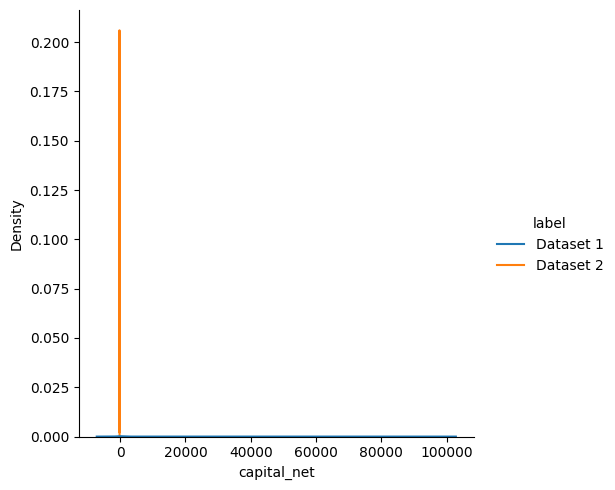

In [54]:
import seaborn as sns
df_reset_copy__ = df_reset_copy_.copy()
synthetic_data_ = synthetic_data.copy()
df_reset_copy__['label'] = 'Dataset 1'
synthetic_data_['label'] = 'Dataset 2'

combined_data = pd.concat([df_reset_copy__, synthetic_data_])

sns.displot(combined_data, x="capital_net", kind="kde", hue='label')

In [55]:
synthetic_data['capital_net'] = round(np.sign(synthetic_data['capital_net_log']) * (np.exp2(abs(synthetic_data['capital_net_log']))+1)).astype(int)

In [56]:
df_reset_copy_ = df_reset_copy_.drop('capital_net_log', axis=1)
synthetic_data = synthetic_data.drop('capital_net_log', axis=1)


In [57]:
df_reset_copy_.to_csv("adult-data-census-complete.csv", index=False)

In [58]:
data = connector.read(
    folder_name='',
    file_names=['adult-data-census-complete.csv'],
    read_csv_parameters={
        'parse_dates': False,
        'encoding':'latin-1'
    }
)

In [59]:
from sdv.metadata import Metadata

metadata = Metadata.detect_from_dataframes(data)

metadata.visualize()
metadata.update_column(
    column_name='education_num',
    sdtype='numerical',
    table_name='adult-data-census-complete'
)

metadata.validate()
metadata.save_to_json('metadata_2.json')

In [ ]:
synthetic_data['input']

In [61]:
metadata_dict = metadata.to_dict()
metadata_dict['columns'] = metadata_dict['tables']['adult-data-census-complete']['columns']

In [62]:
from sdmetrics.reports.single_table import DiagnosticReport

report = DiagnosticReport()
report.generate(df_reset_copy_, synthetic_data, metadata_dict)

/usr/local/lib/python3.12/dist-packages/sdmetrics/reports/single_table/__init__.py:17: FutureWarning: The single table diagnostic report is deprecated. Please use the DiagnosticReport from 'sdmetrics.reports' instead.
  from sdmetrics.reports.single_table.diagnostic_report import DiagnosticReport


Generating report ...

(1/2) Evaluating Data Validity: |██████████| 13/13 [00:00<00:00, 188.56it/s]|
Data Validity Score: 92.31%

(2/2) Evaluating Data Structure: |██████████| 1/1 [00:00<00:00, 355.81it/s]|
Data Structure Score: 100.0%

Overall Score (Average): 96.15%



In [63]:
from sdmetrics.reports.single_table import QualityReport

report = QualityReport()
report.generate(df_reset_copy_, synthetic_data, metadata_dict)

Generating report ...

(1/2) Evaluating Column Shapes: |██████████| 13/13 [00:00<00:00, 101.90it/s]|
Column Shapes Score: 50.78%

(2/2) Evaluating Column Pair Trends: |██████████| 78/78 [00:01<00:00, 70.45it/s]|
Column Pair Trends Score: 31.83%

Overall Score (Average): 41.3%



In [64]:
score_value_fidelity = round(report.get_score(), ndigits=4)
score_value_fidelity = float(score_value_fidelity * 100)

In [65]:
score_value_fidelity

41.3

In [66]:
report.get_properties()

,Property,Score
0,Column Shapes,0.507797
1,Column Pair Trends,0.318259


In [67]:
column_shapes = report.get_details(property_name='Column Shapes')

In [68]:
column_shapes

,Column,Metric,Score
0,age,KSComplement,0.441141
1,workclass,TVComplement,0.753417
2,fnlwgt,KSComplement,0.305089
3,education_num,KSComplement,0.464114
4,marital_status,TVComplement,0.516385
5,occupation,TVComplement,0.049046
6,relationship,TVComplement,0.509782
7,race,TVComplement,0.748503
8,sex,TVComplement,0.928012
9,hours_per_week,KSComplement,0.561009


In [69]:
!pip install seaborn

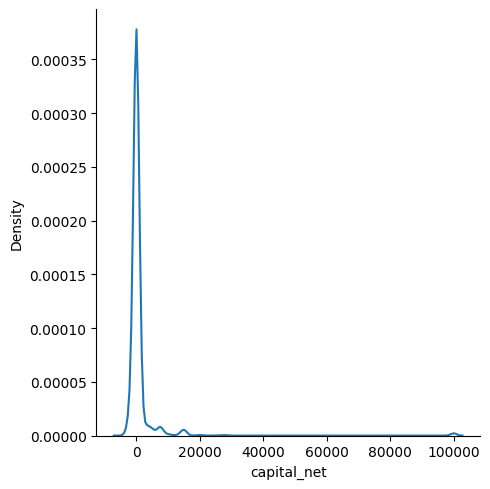

In [70]:
import seaborn as sns

sns.displot(df_reset_copy_, x="capital_net", kind="kde")

/tmp/ipykernel_446/1666709738.py:3: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.displot(synthetic_data[synthetic_data['capital_net']<=40000], x="capital_net", kind="kde")


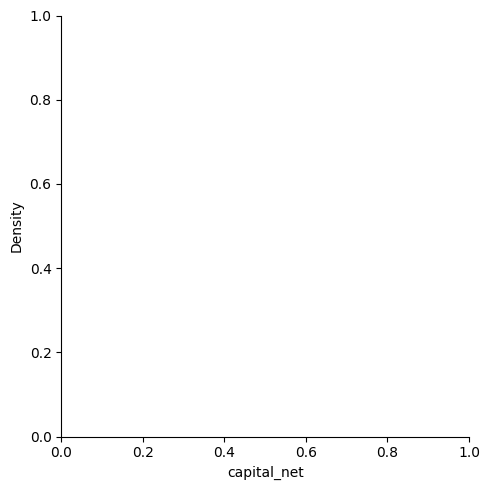

In [71]:
import seaborn as sns

sns.displot(synthetic_data[synthetic_data['capital_net']<=40000], x="capital_net", kind="kde")

Although separate capital_gain and capital_loss provided better values (> higher than 0.9), we tested and the models provided worse results, so we decided to keep the them merged into a single column, capital_net. And they provided a worst result in terms of DQS.

We sensed that capital_loss is zero, when capital_gain > 0, and capital_gain is zero, when capital_loss > 0, so we can create a new column called capital_net, which is the difference between capital_gain and capital_loss, and then we can drop the two columns. This helped the dataset create a more better distribution. We obtained the value of 0.528946 for capital_net.

For capital_net, the distribution of zeros is more pronounced across the real dataset, and the drop in frequence is more abrupt, as compared to the synthetic dataset, which is more linear, and the real dataset has "up and down" fluctuations, while the synthetic dataset is more smooth. In addition, there can be observed an outlier in the real dataset at around 100000, while the synthetic dataset stops at around 20000.

Column shapes, mainly measure differences in distribution between the real and synthetic datasets. For most columns we have values that are okay (>0.85), but for some columns such as 'capital_net', the values are low, for example 0.528946. It can be seen that for 'capital_net', in the real data, there is a very high peak at 0, and the high values are very rare, and there is an outlier at 1000000, but for the synthetic data, the distribution is up-down, it increases and decreases at zero, and then it forms a smaller upward peak at around 6000, and then it sharply decreases, and it remains mostly flat. There no values that are higher than 73582 on the synthetic dataset, while in the real dataset, there are values that are higher than 1000000.

KSComplement measuring using Kolmogorov-Smirnov the similarity in terms of distribution between the real and synthetic datasets, used for numerical and datetime columns. TVComplement, measuring using Total Variation Distance, the same similarity as KSComplement, but for categorical columns.


In order to improve these results, we want to help the learn the heavy skewed distribution of capital_net for the synthetic dataset and after the synthetic dataset is generated, we reverse it back to the original distribution. But now there are a lot of values in the synthetic data that are gathered around 0 for the capital_net column, while having few outliers.

/tmp/ipykernel_446/661864577.py:9: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.displot(combined_data, x="capital_net", kind="kde", hue='label')


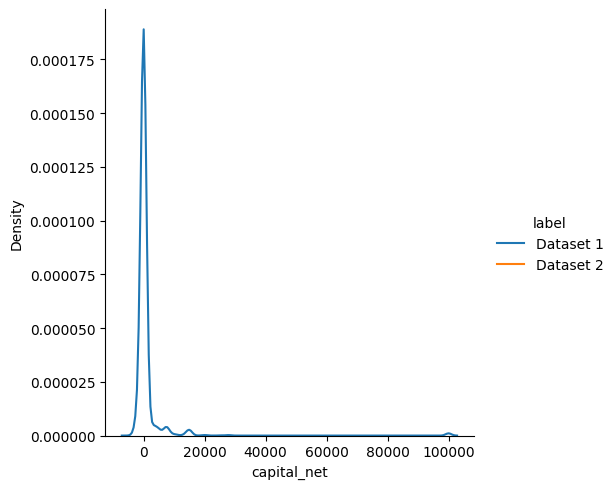

In [72]:
import seaborn as sns
df_reset_copy__ = df_reset_copy_.copy()
synthetic_data_ = synthetic_data.copy()
df_reset_copy__['label'] = 'Dataset 1'
synthetic_data_['label'] = 'Dataset 2'

combined_data = pd.concat([df_reset_copy__, synthetic_data_])

sns.displot(combined_data, x="capital_net", kind="kde", hue='label')

In [73]:

for values in [100, 500, 1000, 2500]:
    x = -values
    y = values
    print("Synthetic data: ", len(synthetic_data[synthetic_data['capital_net']<=y][synthetic_data['capital_net']>=x])/len(synthetic_data), f"values range: [{x}, {y}]")
    print("Real data: ", len(df_reset_copy_[df_reset_copy_['capital_net']<=y][df_reset_copy_['capital_net']>=x])/len(df_reset_copy_), f"values range: [{x}, {y}]")


Synthetic data:  0.0 values range: [-100, 100]
Real data:  0.8700592733638401 values range: [-100, 100]
Synthetic data:  0.0 values range: [-500, 500]
Real data:  0.8706427935259974 values range: [-500, 500]
Synthetic data:  0.0 values range: [-1000, 1000]
Real data:  0.8728540278246982 values range: [-1000, 1000]
Synthetic data:  0.0 values range: [-2500, 2500]
Real data:  0.9255551119437364 values range: [-2500, 2500]


In [74]:
synthetic_data_ = synthetic_data_.drop('label', axis=1)

In [75]:
target_column = 'income'

In [76]:
from sklearn.model_selection import train_test_split
x_train_real, x_test_real, y_train_real, y_test_real = train_test_split(df_reset_copy_.copy().loc[:, df_reset_copy_.columns != target_column], df_reset_copy_.copy().loc[:, df_reset_copy_.columns == target_column], test_size=0.2, random_state=42)
x_train_syn, x_test_syn, y_train_syn, y_test_syn = train_test_split(synthetic_data_.copy().loc[:, synthetic_data_.columns != target_column], synthetic_data_.copy().loc[:, synthetic_data_.columns == target_column], test_size=0.2, random_state=42)

In [77]:
encoder = OneHotEncoder(sparse_output=False)
one_hot_encoded_y_train = encoder.fit_transform(y_train_real)
one_hot_df_y_train = pd.DataFrame(one_hot_encoded_y_train,  columns=encoder.get_feature_names_out(y_train_real.columns), index= y_train_real.index)
y_train_real = pd.concat([one_hot_df_y_train], axis=1)


In [78]:
y_test_real_copy = y_test_real.copy()

In [79]:
one_hot_encoded_y_test = encoder.transform(y_test_real)
one_hot_df_y_test = pd.DataFrame(one_hot_encoded_y_test,  columns=encoder.get_feature_names_out(y_test_real.columns), index= y_test_real.index)
y_test_real = pd.concat([one_hot_df_y_test], axis=1)

In [80]:
encoder = OneHotEncoder(sparse_output=False)
one_hot_encoded_y_train_syn = encoder.fit_transform(y_train_syn)
one_hot_df_y_train_syn = pd.DataFrame(one_hot_encoded_y_train_syn,  columns=encoder.get_feature_names_out(y_train_syn.columns), index= y_train_syn.index)
y_train_syn = pd.concat([one_hot_df_y_train_syn], axis=1)

one_hot_encoded_y_test_syn = encoder.transform(y_test_syn)
one_hot_df_y_test_syn = pd.DataFrame(one_hot_encoded_y_test_syn,  columns=encoder.get_feature_names_out(y_test_syn.columns), index= y_test_syn.index)
y_test_syn = pd.concat([one_hot_df_y_test_syn], axis=1)

one_hot_encoded_y_test_copy = encoder.transform(y_test_real_copy)
one_hot_df_y_test_copy = pd.DataFrame(one_hot_encoded_y_test_copy,  columns=encoder.get_feature_names_out(y_test_real_copy.columns), index= y_test_real_copy.index)
y_test_real_copy = pd.concat([one_hot_df_y_test_copy], axis=1)

In [81]:
is_col_OH.remove(target_column)


In [82]:
x_test_real_copy = x_test_real.copy() 

In [83]:
    encoder = OneHotEncoder(sparse_output=False)
    one_hot_encoded_x_train = encoder.fit_transform(x_train_real[is_col_OH])
    one_hot_df_x_train = pd.DataFrame(one_hot_encoded_x_train,  columns=encoder.get_feature_names_out(is_col_OH), index= x_train_real.index)
    x_train_real = pd.concat([x_train_real.drop(is_col_OH, axis=1), one_hot_df_x_train], axis=1)
    
    one_hot_encoded_x_test = encoder.transform(x_test_real[is_col_OH])
    one_hot_df_x_test = pd.DataFrame(one_hot_encoded_x_test,  columns=encoder.get_feature_names_out(is_col_OH), index= x_test_real.index)
    x_test_real = pd.concat([x_test_real.drop(is_col_OH, axis=1), one_hot_df_x_test], axis=1)


In [84]:
one_hot_encoded_x_train_syn = encoder.transform(x_train_syn[is_col_OH])
one_hot_df_x_train_syn = pd.DataFrame(one_hot_encoded_x_train_syn,  columns=encoder.get_feature_names_out(is_col_OH), index= x_train_syn.index)
x_train_syn = pd.concat([x_train_syn.drop(is_col_OH, axis=1), one_hot_df_x_train_syn], axis=1)

one_hot_encoded_x_test_syn = encoder.transform(x_test_syn[is_col_OH])
one_hot_df_x_test_syn = pd.DataFrame(one_hot_encoded_x_test_syn,  columns=encoder.get_feature_names_out(is_col_OH), index= x_test_syn.index)
x_test_syn = pd.concat([x_test_syn.drop(is_col_OH, axis=1), one_hot_df_x_test_syn], axis=1)

one_hot_encoded_x_test_copy = encoder.transform(x_test_real_copy[is_col_OH])
one_hot_df_x_test_copy = pd.DataFrame(one_hot_encoded_x_test_copy,  columns=encoder.get_feature_names_out(is_col_OH), index= x_test_real_copy.index)
x_test_real_copy = pd.concat([x_test_real_copy.drop(is_col_OH, axis=1), one_hot_df_x_test_copy], axis=1)

In [85]:
from scipy.stats import chi2_contingency
correlated_values_2 = {}
correlated_values_3 = {}

highest_corr_values = []
correlated_columns = set()
value_cosine_similarity = {}
for idx_col_cat in range(len(encoder.get_feature_names_out(is_col_OH))):

    for idx_col_cat_2 in range(idx_col_cat+1, len(encoder.get_feature_names_out(is_col_OH))):
        col_cat = encoder.get_feature_names_out(is_col_OH)[idx_col_cat]
        
        col_cat_2 = encoder.get_feature_names_out(is_col_OH)[idx_col_cat_2]

        
        
        contingency_table = pd.crosstab(x_train_syn[col_cat], x_train_syn[col_cat_2])
        chi2_statistic, p_value, dof, expected = chi2_contingency(contingency_table)
        n = contingency_table.sum().sum()
        phi2 = chi2_statistic / n
        r, k = contingency_table.shape
        if n == 1:
            v = 0
        else: 
            phi2corr = max(0, phi2 - ((k - 1) * (r - 1)) / (n - 1))
            k_corr = k - (k - 1) * (k - 2) / (n - 1)
            r_corr = r - (r - 1) * (r - 2) / (n - 1)
            if k_corr == 1 and r_corr == 1:
                v = 0
            elif k_corr != 1 and r_corr==1:
                v = np.sqrt(phi2corr/(k_corr-1))
            elif r_corr != 1 and k_corr == 1:
                v = np.sqrt(phi2corr/(r_corr-1))
            else:
                v = np.sqrt(phi2corr / min(k_corr - 1, r_corr - 1))
        
        

        if v > 0.5:
            print("v=", v, " col_cat=", col_cat, " col_cat_2=", col_cat_2)
            

        
        if v > 0.6:
            
            if (col_cat, col_cat_2) not in correlated_columns or (col_cat_2, col_cat) not in correlated_columns:
                correlated_columns.add((col_cat, col_cat_2))
            if col_cat in correlated_values_2.keys():
                list_cat = correlated_values_2[col_cat]
                list_cat_2 = correlated_values_3[col_cat]
                list_cat.append((float(v), col_cat_2))
                list_cat_2.append(col_cat_2)
                correlated_values_2[col_cat] = list_cat
                correlated_values_3[col_cat] = list_cat_2

            else:
                correlated_values_2[col_cat] = [(float(v), col_cat_2)]
                correlated_values_3[col_cat] = [col_cat_2]
            
            if col_cat_2 in correlated_values_2.keys():
                list_cat = correlated_values_2[col_cat_2]
                list_cat_2 = correlated_values_3[col_cat_2]
                list_cat.append((float(v), col_cat))
                list_cat_2.append(col_cat)
                correlated_values_2[col_cat_2] = list_cat
                correlated_values_3[col_cat_2] = list_cat_2
            else:
                correlated_values_2[col_cat_2] = [(float(v), col_cat)]
                correlated_values_3[col_cat_2] = [col_cat]
      

v= 0.9996228346444272  col_cat= marital_status_Divorced  col_cat_2= marital_status_Married-civ-spouse
v= 0.9996228346444272  col_cat= marital_status_Divorced  col_cat_2= relationship_Not-in-family
v= 0.9996228346444272  col_cat= marital_status_Married-civ-spouse  col_cat_2= relationship_Not-in-family
v= 0.8901808933608844  col_cat= relationship_Husband  col_cat_2= relationship_Wife
v= 0.7838639835368533  col_cat= relationship_Husband  col_cat_2= race_Black
v= 0.7838639835368533  col_cat= relationship_Husband  col_cat_2= race_White
v= 0.8901808933608844  col_cat= relationship_Husband  col_cat_2= sex_Female
v= 0.8901808933608844  col_cat= relationship_Husband  col_cat_2= sex_Male
v= 0.6975560450985554  col_cat= relationship_Wife  col_cat_2= race_Black
v= 0.6975560450985554  col_cat= relationship_Wife  col_cat_2= race_White
v= 0.9999008339319592  col_cat= relationship_Wife  col_cat_2= sex_Female
v= 0.9999008339319592  col_cat= relationship_Wife  col_cat_2= sex_Male
v= 0.9998960856729725  

In [86]:
if len(y_train_real.columns) == 2 and target_column not in y_train_real.columns:
    y_train_real = y_train_real.drop(y_train_real.columns[0], axis=1)
    y_test_real = y_test_real.drop(y_test_real.columns[0], axis=1)
    y_test_real_copy = y_test_real_copy.drop(y_test_real_copy.columns[0], axis=1)
    y_train_syn = y_train_syn.drop(y_train_syn.columns[0], axis=1)
    y_test_syn = y_test_syn.drop(y_test_syn.columns[0], axis=1)

We use logistic regression, random forest, SVM, KNN and Decision Tree Classifier to evaluate the performance of the synthetic dataset, and we compare it with a real dataset. 


In [87]:
!pip install great_tables

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 19.7 MB/s eta 0:00:0000:010:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 607.2/607.2 kB 39.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 89.6/89.6 kB 7.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 451.0/451.0 kB 29.1 MB/s eta 0:00:00


In [88]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, roc_auc_score, precision_score, recall_score, average_precision_score


model = LogisticRegression(max_iter=10000, n_jobs=-1, C=0.1, random_state=42)
model.fit(x_train_syn, y_train_syn[y_train_syn.columns[0]])
y_pred = model.predict(x_test_real)
print("Accuracy of Logistic Regression model is:", accuracy_score(y_test_real[y_test_real.columns[0]], y_pred)*100, "%")
print("ROC of Logistic Regression model is:", roc_auc_score(y_test_real[y_test_real.columns[0]], y_pred)*100, "%")
print("Precision of Logistic Regression model is:", precision_score(y_test_real[y_test_real.columns[0]], y_pred)*100, "%")
print("Recall of Logistic Regression model is:", recall_score(y_test_real[y_test_real.columns[0]], y_pred)*100, "%")
print("AUPRC of Logistic Regression model is:", average_precision_score(y_test_real[y_test_real.columns[0]], y_pred)*100, "%")

Accuracy of Logistic Regression model is: 24.120988791647473 %
ROC of Logistic Regression model is: 50.0 %
Precision of Logistic Regression model is: 24.120988791647473 %
Recall of Logistic Regression model is: 100.0 %
AUPRC of Logistic Regression model is: 24.120988791647473 %


In [89]:
model_name = "LogisticRegression"
hyper_parameters = "max_iter=10000, C=0.1"
type_ = "synthetic"
values_dict = {}
values_dict["model_name"] = []
values_dict["data_type"] = []
values_dict["hyper_parameters"] = []
values_dict["accuracy"] = []
values_dict["precision"] = []
values_dict["recall"] = []
values_dict["roc_auc"] = []
values_dict["auprc"] = []

values_dict["data_type"].append(type_)
values_dict["model_name"].append(model_name)
values_dict["hyper_parameters"].append(hyper_parameters)
values_dict["accuracy"].append(accuracy_score(y_test_real_copy[y_test_real_copy.columns[0]], y_pred))
values_dict["precision"].append(precision_score(y_test_real_copy[y_test_real_copy.columns[0]], y_pred))
values_dict["recall"].append(recall_score(y_test_real_copy[y_test_real_copy.columns[0]], y_pred))
values_dict["roc_auc"].append(roc_auc_score(y_test_real_copy[y_test_real_copy.columns[0]], y_pred))
values_dict["auprc"].append(average_precision_score(y_test_real_copy[y_test_real_copy.columns[0]], y_pred))

In [90]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, roc_auc_score, precision_score, recall_score, average_precision_score


model = LogisticRegression(max_iter=10000, n_jobs=-1, C=1.0, random_state=42)
model.fit(x_train_syn, y_train_syn[y_train_syn.columns[0]])
y_pred = model.predict(x_test_real)
print("Accuracy of Logistic Regression model is:", accuracy_score(y_test_real[y_test_real.columns[0]], y_pred)*100, "%")
print("ROC of Logistic Regression model is:", roc_auc_score(y_test_real[y_test_real.columns[0]], y_pred)*100, "%")
print("Precision of Logistic Regression model is:", precision_score(y_test_real[y_test_real.columns[0]], y_pred)*100, "%")
print("Recall of Logistic Regression model is:", recall_score(y_test_real[y_test_real.columns[0]], y_pred)*100, "%")
print("AUPRC of Logistic Regression model is:", average_precision_score(y_test_real[y_test_real.columns[0]], y_pred)*100, "%")

Accuracy of Logistic Regression model is: 24.120988791647473 %
ROC of Logistic Regression model is: 50.0 %
Precision of Logistic Regression model is: 24.120988791647473 %
Recall of Logistic Regression model is: 100.0 %
AUPRC of Logistic Regression model is: 24.120988791647473 %


In [91]:
model_name = "LogisticRegression"
hyper_parameters = "max_iter=10000, C=1.0"
type_ = "synthetic"
values_dict["data_type"].append(type_)
values_dict["model_name"].append(model_name)
values_dict["hyper_parameters"].append(hyper_parameters)
values_dict["accuracy"].append(accuracy_score(y_test_real_copy[y_test_real_copy.columns[0]], y_pred))
values_dict["precision"].append(precision_score(y_test_real_copy[y_test_real_copy.columns[0]], y_pred))
values_dict["recall"].append(recall_score(y_test_real_copy[y_test_real_copy.columns[0]], y_pred))
values_dict["roc_auc"].append(roc_auc_score(y_test_real_copy[y_test_real_copy.columns[0]], y_pred))
values_dict["auprc"].append(average_precision_score(y_test_real_copy[y_test_real_copy.columns[0]], y_pred))

In [92]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, roc_auc_score, precision_score, recall_score, average_precision_score


model = LogisticRegression(max_iter=500, n_jobs=-1, C=0.1, random_state=42)
model.fit(x_train_syn, y_train_syn[y_train_syn.columns[0]])
y_pred = model.predict(x_test_real)
print("Accuracy of Logistic Regression model is:", accuracy_score(y_test_real[y_test_real.columns[0]], y_pred)*100, "%")
print("ROC of Logistic Regression model is:", roc_auc_score(y_test_real[y_test_real.columns[0]], y_pred)*100, "%")
print("Precision of Logistic Regression model is:", precision_score(y_test_real[y_test_real.columns[0]], y_pred)*100, "%")
print("Recall of Logistic Regression model is:", recall_score(y_test_real[y_test_real.columns[0]], y_pred)*100, "%")
print("AUPRC of Logistic Regression model is:", average_precision_score(y_test_real[y_test_real.columns[0]], y_pred)*100, "%")

Accuracy of Logistic Regression model is: 24.120988791647473 %
ROC of Logistic Regression model is: 50.0 %
Precision of Logistic Regression model is: 24.120988791647473 %
Recall of Logistic Regression model is: 100.0 %
AUPRC of Logistic Regression model is: 24.120988791647473 %


In [93]:
model_name = "LogisticRegression"
hyper_parameters = "max_iter=500, C=0.1"
type_ = "synthetic"
values_dict["data_type"].append(type_)
values_dict["model_name"].append(model_name)
values_dict["hyper_parameters"].append(hyper_parameters)
values_dict["accuracy"].append(accuracy_score(y_test_real_copy[y_test_real_copy.columns[0]], y_pred))
values_dict["precision"].append(precision_score(y_test_real_copy[y_test_real_copy.columns[0]], y_pred))
values_dict["recall"].append(recall_score(y_test_real_copy[y_test_real_copy.columns[0]], y_pred))
values_dict["roc_auc"].append(roc_auc_score(y_test_real_copy[y_test_real_copy.columns[0]], y_pred))
values_dict["auprc"].append(average_precision_score(y_test_real_copy[y_test_real_copy.columns[0]], y_pred))

In [94]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, roc_auc_score, precision_score, recall_score, average_precision_score


model = LogisticRegression(max_iter=2500, n_jobs=-1, C=0.1, random_state=42)
model.fit(x_train_syn, y_train_syn[y_train_syn.columns[0]])
y_pred = model.predict(x_test_real)
print("Accuracy of Logistic Regression model is:", accuracy_score(y_test_real[y_test_real.columns[0]], y_pred)*100, "%")
print("ROC of Logistic Regression model is:", roc_auc_score(y_test_real[y_test_real.columns[0]], y_pred)*100, "%")
print("Precision of Logistic Regression model is:", precision_score(y_test_real[y_test_real.columns[0]], y_pred)*100, "%")
print("Recall of Logistic Regression model is:", recall_score(y_test_real[y_test_real.columns[0]], y_pred)*100, "%")
print("AUPRC of Logistic Regression model is:", average_precision_score(y_test_real[y_test_real.columns[0]], y_pred)*100, "%")

Accuracy of Logistic Regression model is: 24.120988791647473 %
ROC of Logistic Regression model is: 50.0 %
Precision of Logistic Regression model is: 24.120988791647473 %
Recall of Logistic Regression model is: 100.0 %
AUPRC of Logistic Regression model is: 24.120988791647473 %


In [95]:
model_name = "LogisticRegression"
hyper_parameters = "max_iter=2500, C=0.1"
type_ = "synthetic"
values_dict["data_type"].append(type_)
values_dict["model_name"].append(model_name)
values_dict["hyper_parameters"].append(hyper_parameters)
values_dict["accuracy"].append(accuracy_score(y_test_real_copy[y_test_real_copy.columns[0]], y_pred))
values_dict["precision"].append(precision_score(y_test_real_copy[y_test_real_copy.columns[0]], y_pred))
values_dict["recall"].append(recall_score(y_test_real_copy[y_test_real_copy.columns[0]], y_pred))
values_dict["roc_auc"].append(roc_auc_score(y_test_real_copy[y_test_real_copy.columns[0]], y_pred))
values_dict["auprc"].append(average_precision_score(y_test_real_copy[y_test_real_copy.columns[0]], y_pred))

In [96]:
from sklearn.linear_model import LogisticRegression


model = LogisticRegression(max_iter=10000, n_jobs=-1, C=10.0, random_state=42)
model.fit(x_train_real, y_train_real[y_train_real.columns[0]])
y_pred = model.predict(x_test_real)
print("Accuracy of Logistic Regression model is:", accuracy_score(y_test_real[y_test_real.columns[0]], y_pred)*100, "%")
print("ROC of Logistic Regression model is:", roc_auc_score(y_test_real[y_test_real.columns[0]], y_pred)*100, "%")
print("Precision of Logistic Regression model is:", precision_score(y_test_real[y_test_real.columns[0]], y_pred)*100, "%")
print("Recall of Logistic Regression model is:", recall_score(y_test_real[y_test_real.columns[0]], y_pred)*100, "%")
print("AUPRC of Logistic Regression model is:", average_precision_score(y_test_real[y_test_real.columns[0]], y_pred)*100, "%")


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Accuracy of Logistic Regression model is: 84.86104713649624 %
ROC of Logistic Regression model is: 76.36900586587998 %
Precision of Logistic Regression model is: 72.51732101616628 %
Recall of Logistic Regression model is: 59.961807765754294 %
AUPRC of Logistic Regression model is: 53.14030448578924 %


In [97]:
model_name = "LogisticRegression"
hyper_parameters = "max_iter=10000, C=10.0"
type_ = "real"

values_dict["model_name"].append(model_name)
values_dict["data_type"].append(type_)
values_dict["hyper_parameters"].append(hyper_parameters)
values_dict["accuracy"].append(accuracy_score(y_test_real_copy[y_test_real_copy.columns[0]], y_pred))
values_dict["precision"].append(precision_score(y_test_real_copy[y_test_real_copy.columns[0]], y_pred))
values_dict["recall"].append(recall_score(y_test_real_copy[y_test_real_copy.columns[0]], y_pred))
values_dict["roc_auc"].append(roc_auc_score(y_test_real_copy[y_test_real_copy.columns[0]], y_pred))
values_dict["auprc"].append(average_precision_score(y_test_real_copy[y_test_real_copy.columns[0]], y_pred))

In [98]:
from sklearn.linear_model import LogisticRegression


model = LogisticRegression(max_iter=50, n_jobs=-1, C=0.1, random_state=42)
model.fit(x_train_real, y_train_real[y_train_real.columns[0]])
y_pred = model.predict(x_test_real)
print("Accuracy of Logistic Regression model is:", accuracy_score(y_test_real[y_test_real.columns[0]], y_pred)*100, "%")
print("ROC of Logistic Regression model is:", roc_auc_score(y_test_real[y_test_real.columns[0]], y_pred)*100, "%")
print("Precision of Logistic Regression model is:", precision_score(y_test_real[y_test_real.columns[0]], y_pred)*100, "%")
print("Recall of Logistic Regression model is:", recall_score(y_test_real[y_test_real.columns[0]], y_pred)*100, "%")
print("AUPRC of Logistic Regression model is:", average_precision_score(y_test_real[y_test_real.columns[0]], y_pred)*100, "%")


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Accuracy of Logistic Regression model is: 79.64071856287424 %
ROC of Logistic Regression model is: 59.46921269540161 %
Precision of Logistic Regression model is: 80.7017543859649 %
Recall of Logistic Regression model is: 20.496499045194145 %
AUPRC of Logistic Regression model is: 35.71806487145028 %


In [99]:
model_name = "LogisticRegression"
hyper_parameters = "max_iter=50, C=0.1"
type_ = "real"

values_dict["model_name"].append(model_name)
values_dict["data_type"].append(type_)
values_dict["hyper_parameters"].append(hyper_parameters)
values_dict["accuracy"].append(accuracy_score(y_test_real_copy[y_test_real_copy.columns[0]], y_pred))
values_dict["precision"].append(precision_score(y_test_real_copy[y_test_real_copy.columns[0]], y_pred))
values_dict["recall"].append(recall_score(y_test_real_copy[y_test_real_copy.columns[0]], y_pred))
values_dict["roc_auc"].append(roc_auc_score(y_test_real_copy[y_test_real_copy.columns[0]], y_pred))
values_dict["auprc"].append(average_precision_score(y_test_real_copy[y_test_real_copy.columns[0]], y_pred))

In [100]:
from sklearn.ensemble import RandomForestClassifier
model = RandomForestClassifier()

In [101]:
!pip install polars
!pip install great_tables

^C
ERROR: Operation cancelled by user


In [102]:
model = RandomForestClassifier(max_depth=10, max_samples=0.9, n_estimators=200, n_jobs=-1, random_state=42)
model.fit(x_train_syn, y_train_syn[y_train_syn.columns[0]])
y_pred = model.predict(x_test_real)
print("Accuracy of RandomForestClassifier model is:", accuracy_score(y_test_real[y_test_real.columns[0]], y_pred)*100, "%")
print("ROC of RandomForestClassifier model is:", roc_auc_score(y_test_real[y_test_real.columns[0]], y_pred)*100, "%")
print("Precision of RandomForestClassifier model is:", precision_score(y_test_real[y_test_real.columns[0]], y_pred)*100, "%")
print("Recall of RandomForestClassifier model is:", recall_score(y_test_real[y_test_real.columns[0]], y_pred)*100, "%")
print("AUPRC of RandomForestClassifier model is:", average_precision_score(y_test_real[y_test_real.columns[0]], y_pred)*100, "%")

print(" ")

model = RandomForestClassifier(max_depth=10, max_samples=0.8, n_estimators=50, n_jobs=-1, random_state=42)
model.fit(x_train_syn, y_train_syn[y_train_syn.columns[0]])
y_pred_2 = model.predict(x_test_real)
print("Accuracy of RandomForestClassifier model is:", accuracy_score(y_test_real[y_test_real.columns[0]], y_pred_2)*100, "%")
print("ROC of RandomForestClassifier model is:", roc_auc_score(y_test_real[y_test_real.columns[0]], y_pred_2)*100, "%")
print("Precision of RandomForestClassifier model is:", precision_score(y_test_real[y_test_real.columns[0]], y_pred_2)*100, "%")
print("Recall of RandomForestClassifier model is:", recall_score(y_test_real[y_test_real.columns[0]], y_pred_2)*100, "%")
print("AUPRC of RandomForestClassifier model is:", average_precision_score(y_test_real[y_test_real.columns[0]], y_pred_2)*100, "%")


Accuracy of RandomForestClassifier model is: 24.888684170121294 %
ROC of RandomForestClassifier model is: 50.13680656145985 %
Precision of RandomForestClassifier model is: 24.171721885207653 %
Recall of RandomForestClassifier model is: 98.91788669637174 %
AUPRC of RandomForestClassifier model is: 24.171172895652894 %
 
Accuracy of RandomForestClassifier model is: 24.65837555657915 %
ROC of RandomForestClassifier model is: 50.22385064584959 %
Precision of RandomForestClassifier model is: 24.203526136715126 %
Recall of RandomForestClassifier model is: 99.61807765754297 %
AUPRC of RandomForestClassifier model is: 24.20321090815344 %


In [103]:
model_name = "RandomForestClassifier"
hyper_parameters = "max_depth=10, max_samples=0.9, n_estimators=200"
type_ = "synthetic"

values_dict["model_name"].append(model_name)
values_dict["data_type"].append(type_)
values_dict["hyper_parameters"].append(hyper_parameters)
values_dict["accuracy"].append(accuracy_score(y_test_real_copy[y_test_real_copy.columns[0]], y_pred))
values_dict["precision"].append(precision_score(y_test_real_copy[y_test_real_copy.columns[0]], y_pred))
values_dict["recall"].append(recall_score(y_test_real_copy[y_test_real_copy.columns[0]], y_pred))
values_dict["roc_auc"].append(roc_auc_score(y_test_real_copy[y_test_real_copy.columns[0]], y_pred))
values_dict["auprc"].append(average_precision_score(y_test_real_copy[y_test_real_copy.columns[0]], y_pred))


model_name = "RandomForestClassifier"
hyper_parameters = "max_depth=50, max_samples=0.8, n_estimators=50"
type_ = "synthetic"

values_dict["model_name"].append(model_name)
values_dict["data_type"].append(type_)
values_dict["hyper_parameters"].append(hyper_parameters)
values_dict["accuracy"].append(accuracy_score(y_test_real_copy[y_test_real_copy.columns[0]], y_pred_2))
values_dict["precision"].append(precision_score(y_test_real_copy[y_test_real_copy.columns[0]], y_pred_2))
values_dict["recall"].append(recall_score(y_test_real_copy[y_test_real_copy.columns[0]], y_pred_2))
values_dict["roc_auc"].append(roc_auc_score(y_test_real_copy[y_test_real_copy.columns[0]], y_pred_2))
values_dict["auprc"].append(average_precision_score(y_test_real_copy[y_test_real_copy.columns[0]], y_pred_2))

In [104]:
model = RandomForestClassifier(max_depth=10, max_samples=0.8, n_estimators=100, n_jobs=-1, random_state=42)
model.fit(x_train_syn, y_train_syn[y_train_syn.columns[0]])
y_pred_2 = model.predict(x_test_real)
print("Accuracy of RandomForestClassifier model is:", accuracy_score(y_test_real[y_test_real.columns[0]], y_pred_2)*100, "%")
print("ROC of RandomForestClassifier model is:", roc_auc_score(y_test_real[y_test_real.columns[0]], y_pred_2)*100, "%")
print("Precision of RandomForestClassifier model is:", precision_score(y_test_real[y_test_real.columns[0]], y_pred_2)*100, "%")
print("Recall of RandomForestClassifier model is:", recall_score(y_test_real[y_test_real.columns[0]], y_pred_2)*100, "%")
print("AUPRC of RandomForestClassifier model is:", average_precision_score(y_test_real[y_test_real.columns[0]], y_pred_2)*100, "%")
print(" ")

model = RandomForestClassifier(max_depth=10, max_samples=0.8, n_estimators=200, n_jobs=-1, random_state=42)
model.fit(x_train_syn, y_train_syn[y_train_syn.columns[0]])
y_pred_3 = model.predict(x_test_real)
print("Accuracy of RandomForestClassifier model is:", accuracy_score(y_test_real[y_test_real.columns[0]], y_pred_3)*100, "%")
print("ROC of RandomForestClassifier model is:", roc_auc_score(y_test_real[y_test_real.columns[0]], y_pred_3)*100, "%")
print("Precision of RandomForestClassifier model is:", precision_score(y_test_real[y_test_real.columns[0]], y_pred_3)*100, "%")
print("Recall of RandomForestClassifier model is:", recall_score(y_test_real[y_test_real.columns[0]], y_pred_3)*100, "%")
print("AUPRC of RandomForestClassifier model is:", average_precision_score(y_test_real[y_test_real.columns[0]], y_pred_3)*100, "%")


Accuracy of RandomForestClassifier model is: 24.643021649009672 %
ROC of RandomForestClassifier model is: 50.21373328445744 %
Precision of RandomForestClassifier model is: 24.19978351631359 %
Recall of RandomForestClassifier model is: 99.61807765754297 %
AUPRC of RandomForestClassifier model is: 24.199482581655417 %
 
Accuracy of RandomForestClassifier model is: 24.504836480884386 %
ROC of RandomForestClassifier model is: 50.122677031928106 %
Precision of RandomForestClassifier model is: 24.16615194564546 %
Recall of RandomForestClassifier model is: 99.61807765754297 %
AUPRC of RandomForestClassifier model is: 24.165979457469785 %


In [105]:
model_name = "RandomForestClassifier"
hyper_parameters = "max_depth=10, max_samples=0.8, n_estimators=100"
type_ = "synthetic"

values_dict["model_name"].append(model_name)
values_dict["data_type"].append(type_)
values_dict["hyper_parameters"].append(hyper_parameters)
values_dict["accuracy"].append(accuracy_score(y_test_real_copy[y_test_real_copy.columns[0]], y_pred_2))
values_dict["precision"].append(precision_score(y_test_real_copy[y_test_real_copy.columns[0]], y_pred_2))
values_dict["recall"].append(recall_score(y_test_real_copy[y_test_real_copy.columns[0]], y_pred_2))
values_dict["roc_auc"].append(roc_auc_score(y_test_real_copy[y_test_real_copy.columns[0]], y_pred_2))
values_dict["auprc"].append(average_precision_score(y_test_real_copy[y_test_real_copy.columns[0]], y_pred_2))


model_name = "RandomForestClassifier"
hyper_parameters = "max_depth=10, max_samples=0.8, n_estimators=100"
type_ = "synthetic"

values_dict["model_name"].append(model_name)
values_dict["data_type"].append(type_)
values_dict["hyper_parameters"].append(hyper_parameters)
values_dict["accuracy"].append(accuracy_score(y_test_real_copy[y_test_real_copy.columns[0]], y_pred_3))
values_dict["precision"].append(precision_score(y_test_real_copy[y_test_real_copy.columns[0]], y_pred_3))
values_dict["recall"].append(recall_score(y_test_real_copy[y_test_real_copy.columns[0]], y_pred_3))
values_dict["roc_auc"].append(roc_auc_score(y_test_real_copy[y_test_real_copy.columns[0]], y_pred_3))
values_dict["auprc"].append(average_precision_score(y_test_real_copy[y_test_real_copy.columns[0]], y_pred_3))

In [106]:
model = RandomForestClassifier(max_depth=100, max_samples=0.5, n_estimators=200, n_jobs=-1, random_state=42)
model.fit(x_train_real, y_train_real[y_train_real.columns[0]])
y_pred = model.predict(x_test_real)
print("Accuracy of RandomForestClassifier model is:", accuracy_score(y_test_real[y_test_real.columns[0]], y_pred)*100, "%")
print("ROC of RandomForestClassifier model is:", roc_auc_score(y_test_real[y_test_real.columns[0]], y_pred)*100, "%")
print("Precision of RandomForestClassifier model is:", precision_score(y_test_real[y_test_real.columns[0]], y_pred)*100, "%")
print("Recall of RandomForestClassifier model is:", recall_score(y_test_real[y_test_real.columns[0]], y_pred)*100, "%")
print("AUPRC of RandomForestClassifier model is:", average_precision_score(y_test_real[y_test_real.columns[0]], y_pred)*100, "%")


print(" ")
model = RandomForestClassifier(max_depth=10, max_samples=0.8, n_estimators=100, n_jobs=-1, random_state=42)
model.fit(x_train_real, y_train_real[y_train_real.columns[0]])
y_pred_2 = model.predict(x_test_real)
print("Accuracy of RandomForestClassifier model is:", accuracy_score(y_test_real[y_test_real.columns[0]], y_pred_2)*100, "%")
print("ROC of RandomForestClassifier model is:", roc_auc_score(y_test_real[y_test_real.columns[0]], y_pred_2)*100, "%")
print("Precision of RandomForestClassifier model is:", precision_score(y_test_real[y_test_real.columns[0]], y_pred_2)*100, "%")
print("Recall of RandomForestClassifier model is:", recall_score(y_test_real[y_test_real.columns[0]], y_pred_2)*100, "%")
print("AUPRC of RandomForestClassifier model is:", average_precision_score(y_test_real[y_test_real.columns[0]], y_pred_2)*100, "%")


Accuracy of RandomForestClassifier model is: 86.51926915399969 %
ROC of RandomForestClassifier model is: 78.59057492115411 %
Precision of RandomForestClassifier model is: 76.75675675675676 %
Recall of RandomForestClassifier model is: 63.271801400381925 %
AUPRC of RandomForestClassifier model is: 57.42458736409727 %
 
Accuracy of RandomForestClassifier model is: 86.02794411177645 %
ROC of RandomForestClassifier model is: 75.77022680148926 %
Precision of RandomForestClassifier model is: 80.12762078395625 %
Recall of RandomForestClassifier model is: 55.95162316995545 %
AUPRC of RandomForestClassifier model is: 55.457608474167785 %


In [107]:
model_name = "RandomForestClassifier"
hyper_parameters = "max_depth=100, max_samples=0.5, n_estimators=200"
type_ = "real"

values_dict["model_name"].append(model_name)
values_dict["data_type"].append(type_)
values_dict["hyper_parameters"].append(hyper_parameters)
values_dict["accuracy"].append(accuracy_score(y_test_real_copy[y_test_real_copy.columns[0]], y_pred))
values_dict["precision"].append(precision_score(y_test_real_copy[y_test_real_copy.columns[0]], y_pred))
values_dict["recall"].append(recall_score(y_test_real_copy[y_test_real_copy.columns[0]], y_pred))
values_dict["roc_auc"].append(roc_auc_score(y_test_real_copy[y_test_real_copy.columns[0]], y_pred))
values_dict['auprc'].append(average_precision_score(y_test_real_copy[y_test_real_copy.columns[0]], y_pred))


model_name = "RandomForestClassifier"
hyper_parameters = "max_depth=10, max_samples=0.8, n_estimators=100"
type_ = "real"

values_dict["model_name"].append(model_name)
values_dict["data_type"].append(type_)
values_dict["hyper_parameters"].append(hyper_parameters)
values_dict["accuracy"].append(accuracy_score(y_test_real_copy[y_test_real_copy.columns[0]], y_pred_2))
values_dict["precision"].append(precision_score(y_test_real_copy[y_test_real_copy.columns[0]], y_pred_2))
values_dict["recall"].append(recall_score(y_test_real_copy[y_test_real_copy.columns[0]], y_pred_2))
values_dict["roc_auc"].append(roc_auc_score(y_test_real_copy[y_test_real_copy.columns[0]], y_pred_2))
values_dict['auprc'].append(average_precision_score(y_test_real_copy[y_test_real_copy.columns[0]], y_pred_2))


In [108]:
model = RandomForestClassifier(max_depth=10, max_samples=0.8, n_estimators=200, n_jobs=-1, random_state=42)
model.fit(x_train_real, y_train_real[y_train_real.columns[0]])
y_pred_2 = model.predict(x_test_real)
print("Accuracy of RandomForestClassifier model is:", accuracy_score(y_test_real[y_test_real.columns[0]], y_pred_2)*100, "%")
print("ROC of RandomForestClassifier model is:", roc_auc_score(y_test_real[y_test_real.columns[0]], y_pred_2)*100, "%")
print("Precision of RandomForestClassifier model is:", precision_score(y_test_real[y_test_real.columns[0]], y_pred_2)*100, "%")
print("Recall of RandomForestClassifier model is:", recall_score(y_test_real[y_test_real.columns[0]], y_pred_2)*100, "%")
print("AUPRC of RandomForestClassifier model is:", average_precision_score(y_test_real[y_test_real.columns[0]], y_pred_2)*100, "%")


Accuracy of RandomForestClassifier model is: 85.81298940580378 %
ROC of RandomForestClassifier model is: 75.43319823768573 %
Precision of RandomForestClassifier model is: 79.59743824336688 %
Recall of RandomForestClassifier model is: 55.37873965626989 %
AUPRC of RandomForestClassifier model is: 54.843147304057325 %


In [109]:
model_name = "RandomForestClassifier"
hyper_parameters = "max_depth=10, max_samples=0.8, n_estimators=200"
type_ = "real"

values_dict["model_name"].append(model_name)
values_dict["data_type"].append(type_)
values_dict["hyper_parameters"].append(hyper_parameters)
values_dict["accuracy"].append(accuracy_score(y_test_real_copy[y_test_real_copy.columns[0]], y_pred_2))
values_dict["precision"].append(precision_score(y_test_real_copy[y_test_real_copy.columns[0]], y_pred_2))
values_dict["recall"].append(recall_score(y_test_real_copy[y_test_real_copy.columns[0]], y_pred_2))
values_dict["roc_auc"].append(roc_auc_score(y_test_real_copy[y_test_real_copy.columns[0]], y_pred_2))
values_dict['auprc'].append(average_precision_score(y_test_real_copy[y_test_real_copy.columns[0]], y_pred_2))


In [110]:
from sklearn import svm

model_simple = svm.SVC(
    random_state=42, C=10.0, max_iter=10000, decision_function_shape="ovr"
)
model_simple.fit(x_train_syn, y_train_syn[y_train_syn.columns[0]])
y_pred = model_simple.predict(x_test_real)
print("Accuracy of Logistic Regression model is:", accuracy_score(y_test_real[y_test_real.columns[0]], y_pred)*100, "%")
print("ROC of Logistic Regression model is:", roc_auc_score(y_test_real[y_test_real.columns[0]], y_pred)*100, "%")
print("Precision of Logistic Regression model is:", precision_score(y_test_real[y_test_real.columns[0]], y_pred)*100, "%")
print("Recall of Logistic Regression model is:", recall_score(y_test_real[y_test_real.columns[0]], y_pred)*100, "%")
print("AUPRC of Logistic Regression model is:", average_precision_score(y_test_real[y_test_real.columns[0]], y_pred)*100, "%")

print(" ")

Accuracy of Logistic Regression model is: 24.120988791647473 %
ROC of Logistic Regression model is: 50.0 %
Precision of Logistic Regression model is: 24.120988791647473 %
Recall of Logistic Regression model is: 100.0 %
AUPRC of Logistic Regression model is: 24.120988791647473 %
 


In [111]:
model_name = "svm.SVC"
hyper_parameters = "C=10.0, max_iter=10000, decision_function_shape=ovr"
type_ = "synthetic"

values_dict["model_name"].append(model_name)
values_dict["data_type"].append(type_)
values_dict["hyper_parameters"].append(hyper_parameters)
values_dict["accuracy"].append(accuracy_score(y_test_real_copy[y_test_real_copy.columns[0]], y_pred))
values_dict["precision"].append(precision_score(y_test_real_copy[y_test_real_copy.columns[0]], y_pred))
values_dict["recall"].append(recall_score(y_test_real_copy[y_test_real_copy.columns[0]], y_pred))
values_dict["roc_auc"].append(roc_auc_score(y_test_real_copy[y_test_real_copy.columns[0]], y_pred))
values_dict["auprc"].append(average_precision_score(y_test_real_copy[y_test_real_copy.columns[0]], y_pred))


In [112]:
from sklearn import svm

model_simple = svm.SVC(
    random_state=42, C=10.0, max_iter=5000, decision_function_shape="ovo"
)
model_simple.fit(x_train_syn, y_train_syn[y_train_syn.columns[0]])
y_pred = model_simple.predict(x_test_real)
print("Accuracy of Logistic Regression model is:", accuracy_score(y_test_real[y_test_real.columns[0]], y_pred)*100, "%")
print("ROC of Logistic Regression model is:", roc_auc_score(y_test_real[y_test_real.columns[0]], y_pred)*100, "%")
print("Precision of Logistic Regression model is:", precision_score(y_test_real[y_test_real.columns[0]], y_pred)*100, "%")
print("Recall of Logistic Regression model is:", recall_score(y_test_real[y_test_real.columns[0]], y_pred)*100, "%")
print("AUPRC of Logistic Regression model is:", average_precision_score(y_test_real[y_test_real.columns[0]], y_pred)*100, "%")

print(" ")

/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:305: ConvergenceWarning: Solver terminated early (max_iter=5000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(


Accuracy of Logistic Regression model is: 24.120988791647473 %
ROC of Logistic Regression model is: 50.0 %
Precision of Logistic Regression model is: 24.120988791647473 %
Recall of Logistic Regression model is: 100.0 %
AUPRC of Logistic Regression model is: 24.120988791647473 %
 


In [113]:
model_name = "svm.SVC"
hyper_parameters = "C=10.0, max_iter=5000, decision_function_shape=ovo"
type_ = "synthetic"

values_dict["model_name"].append(model_name)
values_dict["data_type"].append(type_)
values_dict["hyper_parameters"].append(hyper_parameters)
values_dict["accuracy"].append(accuracy_score(y_test_real_copy[y_test_real_copy.columns[0]], y_pred))
values_dict["precision"].append(precision_score(y_test_real_copy[y_test_real_copy.columns[0]], y_pred))
values_dict["recall"].append(recall_score(y_test_real_copy[y_test_real_copy.columns[0]], y_pred))
values_dict["roc_auc"].append(roc_auc_score(y_test_real_copy[y_test_real_copy.columns[0]], y_pred))
values_dict["auprc"].append(average_precision_score(y_test_real_copy[y_test_real_copy.columns[0]], y_pred))


In [114]:
from sklearn import svm

model_simple = svm.SVC(
    random_state=42, C=1.0, max_iter=10000, decision_function_shape="ovo"
)
model_simple.fit(x_train_syn, y_train_syn[y_train_syn.columns[0]])
y_pred = model_simple.predict(x_test_real)
print("Accuracy of Logistic Regression model is:", accuracy_score(y_test_real[y_test_real.columns[0]], y_pred)*100, "%")
print("ROC of Logistic Regression model is:", roc_auc_score(y_test_real[y_test_real.columns[0]], y_pred)*100, "%")
print("Precision of Logistic Regression model is:", precision_score(y_test_real[y_test_real.columns[0]], y_pred)*100, "%")
print("Recall of Logistic Regression model is:", recall_score(y_test_real[y_test_real.columns[0]], y_pred)*100, "%")
print("AUPRC of Logistic Regression model is:", average_precision_score(y_test_real[y_test_real.columns[0]], y_pred)*100, "%")

print(" ")
model_simple = svm.SVC(
    random_state=42, C=10.0, max_iter=1500, decision_function_shape="ovo"
)
model_simple.fit(x_train_syn, y_train_syn[y_train_syn.columns[0]])
y_pred_2 = model_simple.predict(x_test_real)
print("Accuracy of svm.SVC model is:", accuracy_score(y_test_real[y_test_real.columns[0]], y_pred_2)*100, "%")
print("ROC of svm.SVC model is:", roc_auc_score(y_test_real[y_test_real.columns[0]], y_pred_2)*100, "%")
print("Precision of svm.SVC model is:", precision_score(y_test_real[y_test_real.columns[0]], y_pred_2)*100, "%")
print("Recall of svm.SVC model is:", recall_score(y_test_real[y_test_real.columns[0]], y_pred_2)*100, "%")
print("AUPRC of svm.SVC model is:", average_precision_score(y_test_real[y_test_real.columns[0]], y_pred_2)*100, "%")


print(" ")
model_simple = svm.SVC(
    random_state=42, C=100.0, max_iter=6330, decision_function_shape="ovr"
)
model_simple.fit(x_train_syn, y_train_syn[y_train_syn.columns[0]])
y_pred_3 = model_simple.predict(x_test_real)
print("Accuracy of svm.SVC model is:", accuracy_score(y_test_real[y_test_real.columns[0]], y_pred_3)*100, "%")
print("ROC of svm.SVC model is:", roc_auc_score(y_test_real[y_test_real.columns[0]], y_pred_3)*100, "%")
print("Precision of svm.SVC model is:", precision_score(y_test_real[y_test_real.columns[0]], y_pred_3)*100, "%")
print("Recall of svm.SVC model is:", recall_score(y_test_real[y_test_real.columns[0]], y_pred_3)*100, "%")
print("AUPRC of svm.SVC model is:", average_precision_score(y_test_real[y_test_real.columns[0]], y_pred_3)*100, "%")


Accuracy of Logistic Regression model is: 24.120988791647473 %
ROC of Logistic Regression model is: 50.0 %
Precision of Logistic Regression model is: 24.120988791647473 %
Recall of Logistic Regression model is: 100.0 %
AUPRC of Logistic Regression model is: 24.120988791647473 %
 


/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:305: ConvergenceWarning: Solver terminated early (max_iter=1500).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(


Accuracy of svm.SVC model is: 45.401504682941805 %
ROC of svm.SVC model is: 46.65506250610198 %
Precision of svm.SVC model is: 21.859937624043095 %
Recall of svm.SVC model is: 49.07702100572883 %
AUPRC of svm.SVC model is: 23.011332235171995 %
 


/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:305: ConvergenceWarning: Solver terminated early (max_iter=6330).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(


Accuracy of svm.SVC model is: 24.120988791647473 %
ROC of svm.SVC model is: 50.0 %
Precision of svm.SVC model is: 24.120988791647473 %
Recall of svm.SVC model is: 100.0 %
AUPRC of svm.SVC model is: 24.120988791647473 %


In [115]:
model_name = "svm.SVC"
hyper_parameters = "C=1.0, max_iter=10000, decision_function_shape=ovr"
type_ = "synthetic"

values_dict["model_name"].append(model_name)
values_dict["data_type"].append(type_)
values_dict["hyper_parameters"].append(hyper_parameters)
values_dict["accuracy"].append(accuracy_score(y_test_real_copy[y_test_real_copy.columns[0]], y_pred))
values_dict["precision"].append(precision_score(y_test_real_copy[y_test_real_copy.columns[0]], y_pred))
values_dict["recall"].append(recall_score(y_test_real_copy[y_test_real_copy.columns[0]], y_pred))
values_dict["roc_auc"].append(roc_auc_score(y_test_real_copy[y_test_real_copy.columns[0]], y_pred))
values_dict["auprc"].append(average_precision_score(y_test_real_copy[y_test_real_copy.columns[0]], y_pred))

model_name = "svm.SVC"
hyper_parameters = "C=10.0, max_iter=1500, decision_function_shape=ovo"
type_ = "synthetic"

values_dict["model_name"].append(model_name)
values_dict["data_type"].append(type_)
values_dict["hyper_parameters"].append(hyper_parameters)
values_dict["accuracy"].append(accuracy_score(y_test_real_copy[y_test_real_copy.columns[0]], y_pred_2))
values_dict["precision"].append(precision_score(y_test_real_copy[y_test_real_copy.columns[0]], y_pred_2))
values_dict["recall"].append(recall_score(y_test_real_copy[y_test_real_copy.columns[0]], y_pred_2))
values_dict["roc_auc"].append(roc_auc_score(y_test_real_copy[y_test_real_copy.columns[0]], y_pred_2))
values_dict["auprc"].append(average_precision_score(y_test_real_copy[y_test_real_copy.columns[0]], y_pred_2))


model_name = "svm.SVC"
hyper_parameters = "C=100.0, max_iter=6330, decision_function_shape=ovr"
type_ = "synthetic"

values_dict["model_name"].append(model_name)
values_dict["data_type"].append(type_)
values_dict["hyper_parameters"].append(hyper_parameters)
values_dict["accuracy"].append(accuracy_score(y_test_real_copy[y_test_real_copy.columns[0]], y_pred_3))
values_dict["precision"].append(precision_score(y_test_real_copy[y_test_real_copy.columns[0]], y_pred_3))
values_dict["recall"].append(recall_score(y_test_real_copy[y_test_real_copy.columns[0]], y_pred_3))
values_dict["roc_auc"].append(roc_auc_score(y_test_real_copy[y_test_real_copy.columns[0]], y_pred_3))
values_dict["auprc"].append(average_precision_score(y_test_real_copy[y_test_real_copy.columns[0]], y_pred_3))


In [116]:
model_simple = svm.SVC(
    random_state=42, C=10.0, max_iter=10000, decision_function_shape="ovr"
)
model_simple.fit(x_train_real, y_train_real[y_train_real.columns[0]])
y_pred = model_simple.predict(x_test_real)
print("Accuracy of svm.SVC model is:", accuracy_score(y_test_real[y_test_real.columns[0]], y_pred)*100, "%")
print("ROC of svm.SVC model is:", roc_auc_score(y_test_real[y_test_real.columns[0]], y_pred)*100, "%")
print("Precision of svm.SVC model is:", precision_score(y_test_real[y_test_real.columns[0]], y_pred)*100, "%")
print("Recall of svm.SVC model is:", recall_score(y_test_real[y_test_real.columns[0]], y_pred)*100, "%")
print("AUPRC of svm.SVC model is:", average_precision_score(y_test_real[y_test_real.columns[0]], y_pred)*100, "%")

/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:305: ConvergenceWarning: Solver terminated early (max_iter=10000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(


Accuracy of svm.SVC model is: 79.74819591586059 %
ROC of svm.SVC model is: 58.15062619447334 %
Precision of svm.SVC model is: 97.72727272727273 %
Recall of svm.SVC model is: 16.422660725652452 %
AUPRC of svm.SVC model is: 36.209099075155635 %


In [117]:
model_name = "svm.SVC"
hyper_parameters = "C=10.0, max_iter=10000, decision_function_shape=ovr"
type_ = "real"

values_dict["model_name"].append(model_name)
values_dict["data_type"].append(type_)
values_dict["hyper_parameters"].append(hyper_parameters)
values_dict["accuracy"].append(accuracy_score(y_test_real_copy[y_test_real_copy.columns[0]], y_pred))
values_dict["precision"].append(precision_score(y_test_real_copy[y_test_real_copy.columns[0]], y_pred))
values_dict["recall"].append(recall_score(y_test_real_copy[y_test_real_copy.columns[0]], y_pred))
values_dict["roc_auc"].append(roc_auc_score(y_test_real_copy[y_test_real_copy.columns[0]], y_pred))
values_dict["auprc"].append(average_precision_score(y_test_real_copy[y_test_real_copy.columns[0]], y_pred))



In [118]:
model_simple = svm.SVC(
    random_state=42, C=1.0, max_iter=10000, decision_function_shape="ovr"
)
model_simple.fit(x_train_real, y_train_real[y_train_real.columns[0]])
y_pred = model_simple.predict(x_test_real)
print("Accuracy of svm.SVC model is:", accuracy_score(y_test_real[y_test_real.columns[0]], y_pred)*100, "%")
print("ROC of svm.SVC model is:", roc_auc_score(y_test_real[y_test_real.columns[0]], y_pred)*100, "%")
print("Precision of svm.SVC model is:", precision_score(y_test_real[y_test_real.columns[0]], y_pred)*100, "%")
print("Recall of svm.SVC model is:", recall_score(y_test_real[y_test_real.columns[0]], y_pred)*100, "%")
print("AUPRC of svm.SVC model is:", average_precision_score(y_test_real[y_test_real.columns[0]], y_pred)*100, "%")

Accuracy of svm.SVC model is: 79.25687087363734 %
ROC of svm.SVC model is: 57.04532861267083 %
Precision of svm.SVC model is: 99.10714285714286 %
Recall of svm.SVC model is: 14.131126670910248 %
AUPRC of svm.SVC model is: 34.71737720828654 %


In [119]:
model_name = "svm.SVC"
hyper_parameters = "C=1.0, max_iter=10000, decision_function_shape=ovr"
type_ = "real"

values_dict["model_name"].append(model_name)
values_dict["data_type"].append(type_)
values_dict["hyper_parameters"].append(hyper_parameters)
values_dict["accuracy"].append(accuracy_score(y_test_real_copy[y_test_real_copy.columns[0]], y_pred))
values_dict["precision"].append(precision_score(y_test_real_copy[y_test_real_copy.columns[0]], y_pred))
values_dict["recall"].append(recall_score(y_test_real_copy[y_test_real_copy.columns[0]], y_pred))
values_dict["roc_auc"].append(roc_auc_score(y_test_real_copy[y_test_real_copy.columns[0]], y_pred))
values_dict["auprc"].append(average_precision_score(y_test_real_copy[y_test_real_copy.columns[0]], y_pred))



In [120]:
model_simple = svm.SVC(
    random_state=42, C=10.0, max_iter=5000, decision_function_shape="ovr"
)
model_simple.fit(x_train_real, y_train_real[y_train_real.columns[0]])
y_pred = model_simple.predict(x_test_real)
print("Accuracy of svm.SVC model is:", accuracy_score(y_test_real[y_test_real.columns[0]], y_pred)*100, "%")
print("ROC of svm.SVC model is:", roc_auc_score(y_test_real[y_test_real.columns[0]], y_pred)*100, "%")
print("Precision of svm.SVC model is:", precision_score(y_test_real[y_test_real.columns[0]], y_pred)*100, "%")
print("Recall of svm.SVC model is:", recall_score(y_test_real[y_test_real.columns[0]], y_pred)*100, "%")
print("AUPRC of svm.SVC model is:", average_precision_score(y_test_real[y_test_real.columns[0]], y_pred)*100, "%")

/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:305: ConvergenceWarning: Solver terminated early (max_iter=5000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(


Accuracy of svm.SVC model is: 37.80132043605097 %
ROC of svm.SVC model is: 52.08923834751739 %
Precision of svm.SVC model is: 25.120385232744784 %
Recall of svm.SVC model is: 79.69446212603437 %
AUPRC of svm.SVC model is: 24.917452409886703 %


In [121]:
model_name = "svm.SVC"
hyper_parameters = "C=10.0, max_iter=5000, decision_function_shape=ovr"
type_ = "real"

values_dict["model_name"].append(model_name)
values_dict["data_type"].append(type_)
values_dict["hyper_parameters"].append(hyper_parameters)
values_dict["accuracy"].append(accuracy_score(y_test_real_copy[y_test_real_copy.columns[0]], y_pred))
values_dict["precision"].append(precision_score(y_test_real_copy[y_test_real_copy.columns[0]], y_pred))
values_dict["recall"].append(recall_score(y_test_real_copy[y_test_real_copy.columns[0]], y_pred))
values_dict["roc_auc"].append(roc_auc_score(y_test_real_copy[y_test_real_copy.columns[0]], y_pred))
values_dict["auprc"].append(average_precision_score(y_test_real_copy[y_test_real_copy.columns[0]], y_pred))



In [122]:
model_simple = svm.SVC(
    random_state=42, C=10.0, max_iter=5375, decision_function_shape="ovr"
)
model_simple.fit(x_train_real, y_train_real[y_train_real.columns[0]])
y_pred_2 = model_simple.predict(x_test_real)
print("Accuracy of svm.SVC model is:", accuracy_score(y_test_real[y_test_real.columns[0]], y_pred_2)*100, "%")
print("ROC of svm.SVC model is:", roc_auc_score(y_test_real[y_test_real.columns[0]], y_pred_2)*100, "%")
print("Precision of svm.SVC model is:", precision_score(y_test_real[y_test_real.columns[0]], y_pred_2)*100, "%")
print("Recall of svm.SVC model is:", recall_score(y_test_real[y_test_real.columns[0]], y_pred_2)*100, "%")
print("AUPRC of svm.SVC model is:", average_precision_score(y_test_real[y_test_real.columns[0]], y_pred_2)*100, "%")

print(" ")
model_simple = svm.SVC(
    random_state=42, C=0.1, max_iter=500, decision_function_shape="ovo"
)
model_simple.fit(x_train_real, y_train_real[y_train_real.columns[0]])
y_pred_3 = model_simple.predict(x_test_real)
print("Accuracy of svm.SVC model is:", accuracy_score(y_test_real[y_test_real.columns[0]], y_pred_3)*100, "%")
print("ROC of svm.SVC model is:", roc_auc_score(y_test_real[y_test_real.columns[0]], y_pred_3)*100, "%")
print("Precision of svm.SVC model is:", precision_score(y_test_real[y_test_real.columns[0]], y_pred_3)*100, "%")
print("Recall of svm.SVC model is:", recall_score(y_test_real[y_test_real.columns[0]], y_pred_3)*100, "%")
print("AUPRC of svm.SVC model is:", average_precision_score(y_test_real[y_test_real.columns[0]], y_pred_3)*100, "%")


/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:305: ConvergenceWarning: Solver terminated early (max_iter=5375).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(


Accuracy of svm.SVC model is: 53.631199140181174 %
ROC of svm.SVC model is: 52.012839710855985 %
Precision of svm.SVC model is: 25.728643216080403 %
Recall of svm.SVC model is: 48.886059834500315 %
AUPRC of svm.SVC model is: 24.906907695507748 %
 


/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:305: ConvergenceWarning: Solver terminated early (max_iter=500).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(


Accuracy of svm.SVC model is: 36.78796253646553 %
ROC of svm.SVC model is: 51.39978299515629 %
Precision of svm.SVC model is: 24.782091917591124 %
Recall of svm.SVC model is: 79.63080840229154 %
AUPRC of svm.SVC model is: 24.647430555209223 %


In [123]:
model_name = "svm.SVC"
hyper_parameters = "C=10.0, max_iter=5375, decision_function_shape=ovr"
type_ = "real"

values_dict["model_name"].append(model_name)
values_dict["data_type"].append(type_)
values_dict["hyper_parameters"].append(hyper_parameters)
values_dict["accuracy"].append(accuracy_score(y_test_real_copy[y_test_real_copy.columns[0]], y_pred_2))
values_dict["precision"].append(precision_score(y_test_real_copy[y_test_real_copy.columns[0]], y_pred_2))
values_dict["recall"].append(recall_score(y_test_real_copy[y_test_real_copy.columns[0]], y_pred_2))
values_dict["roc_auc"].append(roc_auc_score(y_test_real_copy[y_test_real_copy.columns[0]], y_pred_2))
values_dict["auprc"].append(average_precision_score(y_test_real_copy[y_test_real_copy.columns[0]], y_pred_2))

model_name = "svm.SVC"
hyper_parameters = "C=0.1, max_iter=500, decision_function_shape=ovo"
type_ = "real"

values_dict["model_name"].append(model_name)
values_dict["data_type"].append(type_)
values_dict["hyper_parameters"].append(hyper_parameters)
values_dict["accuracy"].append(accuracy_score(y_test_real_copy[y_test_real_copy.columns[0]], y_pred_3))
values_dict["precision"].append(precision_score(y_test_real_copy[y_test_real_copy.columns[0]], y_pred_3))
values_dict["recall"].append(recall_score(y_test_real_copy[y_test_real_copy.columns[0]], y_pred_3))
values_dict["roc_auc"].append(roc_auc_score(y_test_real_copy[y_test_real_copy.columns[0]], y_pred_3))
values_dict["auprc"].append(average_precision_score(y_test_real_copy[y_test_real_copy.columns[0]], y_pred_3))


In [124]:
is_col_numeric.remove("capital_gain")
is_col_numeric.remove("capital_loss")
is_col_numeric.append("capital_net")

In [125]:
x_train_syn_copy = x_train_syn.copy()
x_test_syn_copy = x_test_syn.copy()

x_train_real_copy = x_train_real.copy()
x_test_real_copy = x_test_real.copy()

In [126]:
y_train_syn_copy = y_train_syn.copy()
y_test_syn_copy = y_test_syn.copy()

y_train_real_copy = y_train_real.copy()
y_test_real_copy = y_test_real.copy()

In [127]:
import pandas as pd
from sklearn import svm
from sklearn.model_selection import RandomizedSearchCV
from sklearn.model_selection import KFold
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
scaler.fit(x_train_syn[is_col_numeric])
x_train_syn_scaled = scaler.transform(x_train_syn[is_col_numeric])
x_test_syn_scaled = scaler.transform(x_test_syn[is_col_numeric])
x_test_real_scaled = scaler.transform(x_test_real[is_col_numeric])
x_train_real_scaled = scaler.transform(x_train_real[is_col_numeric])

In [128]:
x_test_real_copy[is_col_numeric] = x_test_real_scaled
x_train_real_copy[is_col_numeric] = x_train_real_scaled
x_train_syn_copy[is_col_numeric] = x_train_syn_scaled
x_test_syn_copy[is_col_numeric] = x_test_syn_scaled

Precision and recall produce nan values for knn neighbors classifier, so we do not use them.

In [129]:

model_simple = KNeighborsClassifier(n_neighbors=50, leaf_size=200)
model_simple.fit(x_train_syn_scaled, y_train_syn_copy[y_train_syn_copy.columns[0]])
y_pred = model_simple.predict(x_test_real_scaled)
print("Accuracy of KNeighborsClassifier model is:", accuracy_score(y_test_real[y_test_real.columns[0]], y_pred)*100, "%")
print("ROC of KNeighborsClassifier model is:", roc_auc_score(y_test_real[y_test_real.columns[0]], y_pred)*100, "%")
print("Precision of KNeighborsClassifier model is:", precision_score(y_test_real[y_test_real.columns[0]], y_pred)*100, "%")
print("Recall of KNeighborsClassifier model is:", recall_score(y_test_real[y_test_real.columns[0]], y_pred)*100, "%")
print("AUPRC of KNeighborsClassifier model is:", average_precision_score(y_test_real[y_test_real.columns[0]], y_pred)*100, "%")

print(" ")
model_simple = KNeighborsClassifier(n_neighbors=200, leaf_size=200)
model_simple.fit(x_train_syn_scaled, y_train_syn_copy[y_train_syn_copy.columns[0]])
y_pred_2 = model_simple.predict(x_test_real_scaled)
print("Accuracy of KNeighborsClassifier model is:", accuracy_score(y_test_real[y_test_real.columns[0]], y_pred_2)*100, "%")
print("ROC of KNeighborsClassifier model is:", roc_auc_score(y_test_real[y_test_real.columns[0]], y_pred_2)*100, "%")
print("Precision of KNeighborsClassifier model is:", precision_score(y_test_real[y_test_real.columns[0]], y_pred_2)*100, "%")
print("Recall of KNeighborsClassifier model is:", recall_score(y_test_real[y_test_real.columns[0]], y_pred_2)*100, "%")
print("AUPRC of KNeighborsClassifier model is:", average_precision_score(y_test_real[y_test_real.columns[0]], y_pred_2)*100, "%")


Accuracy of KNeighborsClassifier model is: 24.120988791647473 %
ROC of KNeighborsClassifier model is: 50.0 %
Precision of KNeighborsClassifier model is: 24.120988791647473 %
Recall of KNeighborsClassifier model is: 100.0 %
AUPRC of KNeighborsClassifier model is: 24.120988791647473 %
 
Accuracy of KNeighborsClassifier model is: 24.120988791647473 %
ROC of KNeighborsClassifier model is: 50.0 %
Precision of KNeighborsClassifier model is: 24.120988791647473 %
Recall of KNeighborsClassifier model is: 100.0 %
AUPRC of KNeighborsClassifier model is: 24.120988791647473 %


In [130]:
model_name = "KNeighborsClassifier"
hyper_parameters = "n_neighbors=50, leaf_size=200"
type_ = "synthetic"

values_dict["model_name"].append(model_name)
values_dict["data_type"].append(type_)
values_dict["hyper_parameters"].append(hyper_parameters)
values_dict["accuracy"].append(accuracy_score(y_test_real_copy[y_test_real_copy.columns[0]], y_pred))
values_dict["precision"].append(precision_score(y_test_real_copy[y_test_real_copy.columns[0]], y_pred))
values_dict["recall"].append(recall_score(y_test_real_copy[y_test_real_copy.columns[0]], y_pred))
values_dict["roc_auc"].append(roc_auc_score(y_test_real_copy[y_test_real_copy.columns[0]], y_pred))
values_dict["auprc"].append(average_precision_score(y_test_real_copy[y_test_real_copy.columns[0]], y_pred))

model_name = "KNeighborsClassifier"
hyper_parameters = "n_neighbors=200, leaf_size=200"
type_ = "synthetic"

values_dict["model_name"].append(model_name)
values_dict["data_type"].append(type_)
values_dict["hyper_parameters"].append(hyper_parameters)
values_dict["accuracy"].append(accuracy_score(y_test_real_copy[y_test_real_copy.columns[0]], y_pred_2))
values_dict["precision"].append(precision_score(y_test_real_copy[y_test_real_copy.columns[0]], y_pred_2))
values_dict["recall"].append(recall_score(y_test_real_copy[y_test_real_copy.columns[0]], y_pred_2))
values_dict["roc_auc"].append(roc_auc_score(y_test_real_copy[y_test_real_copy.columns[0]], y_pred_2))
values_dict["auprc"].append(average_precision_score(y_test_real_copy[y_test_real_copy.columns[0]], y_pred_2))

In [131]:
model_simple = KNeighborsClassifier(n_neighbors=5, leaf_size=200)
model_simple.fit(x_train_syn_scaled, y_train_syn_copy[y_train_syn_copy.columns[0]])
y_pred = model_simple.predict(x_test_real_scaled)
print("Accuracy of KNeighborsClassifier model is:", accuracy_score(y_test_real[y_test_real.columns[0]], y_pred)*100, "%")
print("ROC of KNeighborsClassifier model is:", roc_auc_score(y_test_real[y_test_real.columns[0]], y_pred)*100, "%")
print("Precision of KNeighborsClassifier model is:", precision_score(y_test_real[y_test_real.columns[0]], y_pred)*100, "%")
print("Recall of KNeighborsClassifier model is:", recall_score(y_test_real[y_test_real.columns[0]], y_pred)*100, "%")
print("AUPRC of KNeighborsClassifier model is:", average_precision_score(y_test_real[y_test_real.columns[0]], y_pred)*100, "%")

print(" ")

Accuracy of KNeighborsClassifier model is: 26.239828036235224 %
ROC of KNeighborsClassifier model is: 50.37584934959084 %
Precision of KNeighborsClassifier model is: 24.263652284668048 %
Recall of KNeighborsClassifier model is: 97.00827498408657 %
AUPRC of KNeighborsClassifier model is: 24.259384185258774 %
 


In [132]:
model_name = "KNeighborsClassifier"
hyper_parameters = "n_neighbors=5, leaf_size=200"
type_ = "synthetic"

values_dict["model_name"].append(model_name)
values_dict["data_type"].append(type_)
values_dict["hyper_parameters"].append(hyper_parameters)
values_dict["accuracy"].append(accuracy_score(y_test_real_copy[y_test_real_copy.columns[0]], y_pred))
values_dict["precision"].append(precision_score(y_test_real_copy[y_test_real_copy.columns[0]], y_pred))
values_dict["recall"].append(recall_score(y_test_real_copy[y_test_real_copy.columns[0]], y_pred))
values_dict["roc_auc"].append(roc_auc_score(y_test_real_copy[y_test_real_copy.columns[0]], y_pred))
values_dict["auprc"].append(average_precision_score(y_test_real_copy[y_test_real_copy.columns[0]], y_pred))


In [133]:
model_simple = KNeighborsClassifier(n_neighbors=50, leaf_size=30)
model_simple.fit(x_train_real_scaled, y_train_real_copy[y_train_real_copy.columns[0]])
y_pred = model_simple.predict(x_test_real_scaled)
print("Accuracy of KNeighborsClassifier model is:", accuracy_score(y_test_real[y_test_real.columns[0]], y_pred)*100, "%")
print("ROC of KNeighborsClassifier model is:", roc_auc_score(y_test_real[y_test_real.columns[0]], y_pred)*100, "%")
print("Precision of KNeighborsClassifier model is:", precision_score(y_test_real[y_test_real.columns[0]], y_pred)*100, "%")
print("Recall of KNeighborsClassifier model is:", recall_score(y_test_real[y_test_real.columns[0]], y_pred)*100, "%")
print("AUPRC of KNeighborsClassifier model is:", average_precision_score(y_test_real[y_test_real.columns[0]], y_pred)*100, "%")


Accuracy of KNeighborsClassifier model is: 82.2815906648242 %
ROC of KNeighborsClassifier model is: 64.85659493536869 %
Precision of KNeighborsClassifier model is: 87.03374777975134 %
Recall of KNeighborsClassifier model is: 31.19032463399109 %
AUPRC of KNeighborsClassifier model is: 43.74368255623748 %


In [134]:
model_name = "KNeighborsClassifier"
hyper_parameters = "n_neighbors=50, leaf_size=30"
type_ = "real"

values_dict["model_name"].append(model_name)
values_dict["data_type"].append(type_)
values_dict["hyper_parameters"].append(hyper_parameters)
values_dict["accuracy"].append(accuracy_score(y_test_real_copy[y_test_real_copy.columns[0]], y_pred))
values_dict["precision"].append(precision_score(y_test_real_copy[y_test_real_copy.columns[0]], y_pred))
values_dict["recall"].append(recall_score(y_test_real_copy[y_test_real_copy.columns[0]], y_pred))
values_dict["roc_auc"].append(roc_auc_score(y_test_real_copy[y_test_real_copy.columns[0]], y_pred))
values_dict["auprc"].append(average_precision_score(y_test_real_copy[y_test_real_copy.columns[0]], y_pred))

In [135]:
model_simple = KNeighborsClassifier(n_neighbors=5, leaf_size=200)
model_simple.fit(x_train_real_scaled, y_train_real_copy[y_train_real_copy.columns[0]])
y_pred = model_simple.predict(x_test_real_scaled)
print("Accuracy of KNeighborsClassifier model is:", accuracy_score(y_test_real[y_test_real.columns[0]], y_pred)*100, "%")
print("ROC of KNeighborsClassifier model is:", roc_auc_score(y_test_real[y_test_real.columns[0]], y_pred)*100, "%")
print("Precision of KNeighborsClassifier model is:", precision_score(y_test_real[y_test_real.columns[0]], y_pred)*100, "%")
print("Recall of KNeighborsClassifier model is:", recall_score(y_test_real[y_test_real.columns[0]], y_pred)*100, "%")
print("AUPRC of KNeighborsClassifier model is:", average_precision_score(y_test_real[y_test_real.columns[0]], y_pred)*100, "%")


Accuracy of KNeighborsClassifier model is: 80.34699831107017 %
ROC of KNeighborsClassifier model is: 67.79345049293639 %
Precision of KNeighborsClassifier model is: 63.50974930362116 %
Recall of KNeighborsClassifier model is: 43.539147040101845 %
AUPRC of KNeighborsClassifier model is: 41.27051914822927 %


In [136]:
model_name = "KNeighborsClassifier"
hyper_parameters = "n_neighbors=5, leaf_size=200"
type_ = "real"

values_dict["model_name"].append(model_name)
values_dict["data_type"].append(type_)
values_dict["hyper_parameters"].append(hyper_parameters)
values_dict["accuracy"].append(accuracy_score(y_test_real_copy[y_test_real_copy.columns[0]], y_pred))
values_dict["precision"].append(precision_score(y_test_real_copy[y_test_real_copy.columns[0]], y_pred))
values_dict["recall"].append(recall_score(y_test_real_copy[y_test_real_copy.columns[0]], y_pred))
values_dict["roc_auc"].append(roc_auc_score(y_test_real_copy[y_test_real_copy.columns[0]], y_pred))
values_dict["auprc"].append(average_precision_score(y_test_real_copy[y_test_real_copy.columns[0]], y_pred))

In [137]:
model_simple = KNeighborsClassifier(n_neighbors=200, leaf_size=50)
model_simple.fit(x_train_real_scaled, y_train_real_copy[y_train_real_copy.columns[0]])
y_pred = model_simple.predict(x_test_real_scaled)
print("Accuracy of KNeighborsClassifier model is:", accuracy_score(y_test_real[y_test_real.columns[0]], y_pred)*100, "%")
print("ROC of KNeighborsClassifier model is:", roc_auc_score(y_test_real[y_test_real.columns[0]], y_pred)*100, "%")
print("Precision of KNeighborsClassifier model is:", precision_score(y_test_real[y_test_real.columns[0]], y_pred)*100, "%")
print("Recall of KNeighborsClassifier model is:", recall_score(y_test_real[y_test_real.columns[0]], y_pred)*100, "%")
print("AUPRC of KNeighborsClassifier model is:", average_precision_score(y_test_real[y_test_real.columns[0]], y_pred)*100, "%")


Accuracy of KNeighborsClassifier model is: 81.437125748503 %
ROC of KNeighborsClassifier model is: 63.17124603387841 %
Precision of KNeighborsClassifier model is: 85.21400778210116 %
Recall of KNeighborsClassifier model is: 27.880330999363462 %
AUPRC of KNeighborsClassifier model is: 41.15392470368994 %


In [138]:
model_name = "KNeighborsClassifier"
hyper_parameters = "n_neighbors=200, leaf_size=50"
type_ = "real"

values_dict["model_name"].append(model_name)
values_dict["data_type"].append(type_)
values_dict["hyper_parameters"].append(hyper_parameters)
values_dict["accuracy"].append(accuracy_score(y_test_real_copy[y_test_real_copy.columns[0]], y_pred))
values_dict["precision"].append(precision_score(y_test_real_copy[y_test_real_copy.columns[0]], y_pred))
values_dict["recall"].append(recall_score(y_test_real_copy[y_test_real_copy.columns[0]], y_pred))
values_dict["roc_auc"].append(roc_auc_score(y_test_real_copy[y_test_real_copy.columns[0]], y_pred))
values_dict["auprc"].append(average_precision_score(y_test_real_copy[y_test_real_copy.columns[0]], y_pred))

In [139]:
model_simple = KNeighborsClassifier(n_neighbors=50, leaf_size=2)
model_simple.fit(x_train_real_scaled, y_train_real_copy[y_train_real_copy.columns[0]])
y_pred_2 = model_simple.predict(x_test_real_scaled)
print("Accuracy of KNeighborsClassifier model is:", accuracy_score(y_test_real[y_test_real.columns[0]], y_pred_2)*100, "%")
print("ROC of KNeighborsClassifier model is:", roc_auc_score(y_test_real[y_test_real.columns[0]], y_pred_2)*100, "%")
print("Precision of KNeighborsClassifier model is:", precision_score(y_test_real[y_test_real.columns[0]], y_pred_2)*100, "%")
print("Recall of KNeighborsClassifier model is:", recall_score(y_test_real[y_test_real.columns[0]], y_pred_2)*100, "%")
print("AUPRC of KNeighborsClassifier model is:", average_precision_score(y_test_real[y_test_real.columns[0]], y_pred_2)*100, "%")

Accuracy of KNeighborsClassifier model is: 82.2815906648242 %
ROC of KNeighborsClassifier model is: 64.85659493536869 %
Precision of KNeighborsClassifier model is: 87.03374777975134 %
Recall of KNeighborsClassifier model is: 31.19032463399109 %
AUPRC of KNeighborsClassifier model is: 43.74368255623748 %


In [140]:
model_name = "KNeighborsClassifier"
hyper_parameters = "n_neighbors=50, leaf_size=2"
type_ = "real"

values_dict["model_name"].append(model_name)
values_dict["data_type"].append(type_)
values_dict["hyper_parameters"].append(hyper_parameters)
values_dict["accuracy"].append(accuracy_score(y_test_real_copy[y_test_real_copy.columns[0]], y_pred_2))
values_dict["precision"].append(precision_score(y_test_real_copy[y_test_real_copy.columns[0]], y_pred_2))
values_dict["recall"].append(recall_score(y_test_real_copy[y_test_real_copy.columns[0]], y_pred_2))
values_dict["roc_auc"].append(roc_auc_score(y_test_real_copy[y_test_real_copy.columns[0]], y_pred_2))
values_dict["auprc"].append(average_precision_score(y_test_real_copy[y_test_real_copy.columns[0]], y_pred_2))


In [141]:
model_simple = DecisionTreeClassifier(criterion='entropy', min_samples_split=50, min_samples_leaf=100)
model_simple.fit(x_train_syn, y_train_syn_copy[y_train_syn_copy.columns[0]])
y_pred = model_simple.predict(x_test_real)
print("Accuracy of DecisionTreeClassifier model is:", accuracy_score(y_test_real[y_test_real.columns[0]], y_pred)*100, "%")
print("ROC of DecisionTreeClassifier model is:", roc_auc_score(y_test_real[y_test_real.columns[0]], y_pred)*100, "%")
print("Precision of DecisionTreeClassifier model is:", precision_score(y_test_real[y_test_real.columns[0]], y_pred)*100, "%")
print("Recall of DecisionTreeClassifier model is:", recall_score(y_test_real[y_test_real.columns[0]], y_pred)*100, "%")
print("AUPRC of DecisionTreeClassifier model is:", average_precision_score(y_test_real[y_test_real.columns[0]], y_pred)*100, "%")

print(" ")

Accuracy of DecisionTreeClassifier model is: 24.120988791647473 %
ROC of DecisionTreeClassifier model is: 50.0 %
Precision of DecisionTreeClassifier model is: 24.120988791647473 %
Recall of DecisionTreeClassifier model is: 100.0 %
AUPRC of DecisionTreeClassifier model is: 24.120988791647473 %
 


In [142]:
model_name = "DecisionTreeClassifier"
hyper_parameters = "criterion='entropy', min_samples_split=50, min_samples_leaf=100"
type_ = "synthetic"

values_dict["model_name"].append(model_name)
values_dict["data_type"].append(type_)
values_dict["hyper_parameters"].append(hyper_parameters)
values_dict["accuracy"].append(accuracy_score(y_test_real_copy[y_test_real_copy.columns[0]], y_pred))
values_dict["precision"].append(precision_score(y_test_real_copy[y_test_real_copy.columns[0]], y_pred))
values_dict["recall"].append(recall_score(y_test_real_copy[y_test_real_copy.columns[0]], y_pred))
values_dict["roc_auc"].append(roc_auc_score(y_test_real_copy[y_test_real_copy.columns[0]], y_pred))
values_dict["auprc"].append(average_precision_score(y_test_real_copy[y_test_real_copy.columns[0]], y_pred))


In [143]:
model_simple = DecisionTreeClassifier(criterion='gini', min_samples_split=20, min_samples_leaf=100)
model_simple.fit(x_train_syn, y_train_syn_copy[y_train_syn_copy.columns[0]])
y_pred = model_simple.predict(x_test_real)
print("Accuracy of DecisionTreeClassifier model is:", accuracy_score(y_test_real[y_test_real.columns[0]], y_pred)*100, "%")
print("ROC of DecisionTreeClassifier model is:", roc_auc_score(y_test_real[y_test_real.columns[0]], y_pred)*100, "%")
print("Precision of DecisionTreeClassifier model is:", precision_score(y_test_real[y_test_real.columns[0]], y_pred)*100, "%")
print("Recall of DecisionTreeClassifier model is:", recall_score(y_test_real[y_test_real.columns[0]], y_pred)*100, "%")
print("AUPRC of DecisionTreeClassifier model is:", average_precision_score(y_test_real[y_test_real.columns[0]], y_pred)*100, "%")

print(" ")

Accuracy of DecisionTreeClassifier model is: 24.120988791647473 %
ROC of DecisionTreeClassifier model is: 50.0 %
Precision of DecisionTreeClassifier model is: 24.120988791647473 %
Recall of DecisionTreeClassifier model is: 100.0 %
AUPRC of DecisionTreeClassifier model is: 24.120988791647473 %
 


In [144]:
model_name = "DecisionTreeClassifier"
hyper_parameters = "criterion='gini', min_samples_split=20, min_samples_leaf=100"
type_ = "synthetic"

values_dict["model_name"].append(model_name)
values_dict["data_type"].append(type_)
values_dict["hyper_parameters"].append(hyper_parameters)
values_dict["accuracy"].append(accuracy_score(y_test_real_copy[y_test_real_copy.columns[0]], y_pred))
values_dict["precision"].append(precision_score(y_test_real_copy[y_test_real_copy.columns[0]], y_pred))
values_dict["recall"].append(recall_score(y_test_real_copy[y_test_real_copy.columns[0]], y_pred))
values_dict["roc_auc"].append(roc_auc_score(y_test_real_copy[y_test_real_copy.columns[0]], y_pred))
values_dict["auprc"].append(average_precision_score(y_test_real_copy[y_test_real_copy.columns[0]], y_pred))


In [145]:
model_simple = DecisionTreeClassifier(criterion='log_loss', min_samples_split=20, min_samples_leaf=100)
model_simple.fit(x_train_syn, y_train_syn_copy[y_train_syn_copy.columns[0]])
y_pred = model_simple.predict(x_test_real)
print("Accuracy of DecisionTreeClassifier model is:", accuracy_score(y_test_real[y_test_real.columns[0]], y_pred)*100, "%")
print("ROC of DecisionTreeClassifier model is:", roc_auc_score(y_test_real[y_test_real.columns[0]], y_pred)*100, "%")
print("Precision of DecisionTreeClassifier model is:", precision_score(y_test_real[y_test_real.columns[0]], y_pred)*100, "%")
print("Recall of DecisionTreeClassifier model is:", recall_score(y_test_real[y_test_real.columns[0]], y_pred)*100, "%")
print("AUPRC of DecisionTreeClassifier model is:", average_precision_score(y_test_real[y_test_real.columns[0]], y_pred)*100, "%")
print(" ")
model_simple = DecisionTreeClassifier(criterion='log_loss', min_samples_split=2, min_samples_leaf=1)
model_simple.fit(x_train_syn, y_train_syn_copy[y_train_syn_copy.columns[0]])
y_pred_2 = model_simple.predict(x_test_real)
print("Accuracy of DecisionTreeClassifier model is:", accuracy_score(y_test_real[y_test_real.columns[0]], y_pred_2)*100, "%")
print("ROC of DecisionTreeClassifier model is:", roc_auc_score(y_test_real[y_test_real.columns[0]], y_pred_2)*100, "%")
print("Precision of DecisionTreeClassifier model is:", precision_score(y_test_real[y_test_real.columns[0]], y_pred_2)*100, "%")
print("Recall of DecisionTreeClassifier model is:", recall_score(y_test_real[y_test_real.columns[0]], y_pred_2)*100, "%")
print("AUPRC of DecisionTreeClassifier model is:", average_precision_score(y_test_real[y_test_real.columns[0]], y_pred_2)*100, "%")

Accuracy of DecisionTreeClassifier model is: 24.120988791647473 %
ROC of DecisionTreeClassifier model is: 50.0 %
Precision of DecisionTreeClassifier model is: 24.120988791647473 %
Recall of DecisionTreeClassifier model is: 100.0 %
AUPRC of DecisionTreeClassifier model is: 24.120988791647473 %
 
Accuracy of DecisionTreeClassifier model is: 29.448794718255794 %
ROC of DecisionTreeClassifier model is: 53.054824893011 %
Precision of DecisionTreeClassifier model is: 25.310254735467012 %
Recall of DecisionTreeClassifier model is: 98.66327180140038 %
AUPRC of DecisionTreeClassifier model is: 25.294357482239636 %


In [146]:
model_name = "DecisionTreeClassifier"
hyper_parameters = "criterion='log_loss', min_samples_split=20, min_samples_leaf=100"
type_ = "synthetic"

values_dict["model_name"].append(model_name)
values_dict["data_type"].append(type_)
values_dict["hyper_parameters"].append(hyper_parameters)
values_dict["accuracy"].append(accuracy_score(y_test_real_copy[y_test_real_copy.columns[0]], y_pred))
values_dict["precision"].append(precision_score(y_test_real_copy[y_test_real_copy.columns[0]], y_pred))
values_dict["recall"].append(recall_score(y_test_real_copy[y_test_real_copy.columns[0]], y_pred))
values_dict["roc_auc"].append(roc_auc_score(y_test_real_copy[y_test_real_copy.columns[0]], y_pred))
values_dict["auprc"].append(average_precision_score(y_test_real_copy[y_test_real_copy.columns[0]], y_pred))

model_name = "DecisionTreeClassifier"
hyper_parameters = "criterion='log_loss', min_samples_split=2, min_samples_leaf=1"
type_ = "synthetic"

values_dict["model_name"].append(model_name)
values_dict["data_type"].append(type_)
values_dict["hyper_parameters"].append(hyper_parameters)
values_dict["accuracy"].append(accuracy_score(y_test_real_copy[y_test_real_copy.columns[0]], y_pred_2))
values_dict["precision"].append(precision_score(y_test_real_copy[y_test_real_copy.columns[0]], y_pred_2))
values_dict["recall"].append(recall_score(y_test_real_copy[y_test_real_copy.columns[0]], y_pred_2))
values_dict["roc_auc"].append(roc_auc_score(y_test_real_copy[y_test_real_copy.columns[0]], y_pred_2))
values_dict["auprc"].append(average_precision_score(y_test_real_copy[y_test_real_copy.columns[0]], y_pred_2))


In [147]:
model_simple = DecisionTreeClassifier(criterion='entropy', min_samples_split=50, min_samples_leaf=100)
model_simple.fit(x_train_real, y_train_real_copy[y_train_real_copy.columns[0]])
y_pred = model_simple.predict(x_test_real)
print("Accuracy of DecisionTreeClassifier model is:", accuracy_score(y_test_real[y_test_real.columns[0]], y_pred)*100, "%")
print("ROC of DecisionTreeClassifier model is:", roc_auc_score(y_test_real[y_test_real.columns[0]], y_pred)*100, "%")
print("Precision of DecisionTreeClassifier model is:", precision_score(y_test_real[y_test_real.columns[0]], y_pred)*100, "%")
print("Recall of DecisionTreeClassifier model is:", recall_score(y_test_real[y_test_real.columns[0]], y_pred)*100, "%")
print("AUPRC of DecisionTreeClassifier model is:", average_precision_score(y_test_real[y_test_real.columns[0]], y_pred)*100, "%")


Accuracy of DecisionTreeClassifier model is: 85.45984953170583 %
ROC of DecisionTreeClassifier model is: 75.67810793621025 %
Precision of DecisionTreeClassifier model is: 76.89655172413794 %
Recall of DecisionTreeClassifier model is: 56.77912157861235 %
AUPRC of DecisionTreeClassifier model is: 54.0864898328833 %


In [148]:
model_name = "DecisionTreeClassifier"
hyper_parameters = "criterion='entropy', min_samples_split=50, min_samples_leaf=100"
type_ = "real"

values_dict["model_name"].append(model_name)
values_dict["data_type"].append(type_)
values_dict["hyper_parameters"].append(hyper_parameters)
values_dict["accuracy"].append(accuracy_score(y_test_real_copy[y_test_real_copy.columns[0]], y_pred))
values_dict["precision"].append(precision_score(y_test_real_copy[y_test_real_copy.columns[0]], y_pred))
values_dict["recall"].append(recall_score(y_test_real_copy[y_test_real_copy.columns[0]], y_pred))
values_dict["roc_auc"].append(roc_auc_score(y_test_real_copy[y_test_real_copy.columns[0]], y_pred))
values_dict["auprc"].append(average_precision_score(y_test_real_copy[y_test_real_copy.columns[0]], y_pred))


In [149]:
model_simple = DecisionTreeClassifier(criterion='gini', min_samples_split=200, min_samples_leaf=1)
model_simple.fit(x_train_real, y_train_real_copy[y_train_real_copy.columns[0]])
y_pred_2 = model_simple.predict(x_test_real)
print("Accuracy of DecisionTreeClassifier model is:", accuracy_score(y_test_real[y_test_real.columns[0]], y_pred_2)*100, "%")
print("ROC of DecisionTreeClassifier model is:", roc_auc_score(y_test_real[y_test_real.columns[0]], y_pred_2)*100, "%")
print("Precision of DecisionTreeClassifier model is:", precision_score(y_test_real[y_test_real.columns[0]], y_pred_2)*100, "%")
print("Recall of DecisionTreeClassifier model is:", recall_score(y_test_real[y_test_real.columns[0]], y_pred_2)*100, "%")
print("AUPRC of DecisionTreeClassifier model is:", average_precision_score(y_test_real[y_test_real.columns[0]], y_pred_2)*100, "%")

print(" ")


Accuracy of DecisionTreeClassifier model is: 86.42714570858283 %
ROC of DecisionTreeClassifier model is: 78.63841825519758 %
Precision of DecisionTreeClassifier model is: 76.20137299771167 %
Recall of DecisionTreeClassifier model is: 63.59007001909611 %
AUPRC of DecisionTreeClassifier model is: 57.23894157449797 %
 


In [150]:
model_simple = DecisionTreeClassifier(criterion='entropy', min_samples_split=50, min_samples_leaf=100)
model_simple.fit(x_train_real, y_train_real_copy[y_train_real_copy.columns[0]])
y_pred_3 = model_simple.predict(x_test_real)
print("Accuracy of DecisionTreeClassifier model is:", accuracy_score(y_test_real[y_test_real.columns[0]], y_pred_3)*100, "%")
print("ROC of DecisionTreeClassifier model is:", roc_auc_score(y_test_real[y_test_real.columns[0]], y_pred_3)*100, "%")
print("Precision of DecisionTreeClassifier model is:", precision_score(y_test_real[y_test_real.columns[0]], y_pred_3)*100, "%")
print("Recall of DecisionTreeClassifier model is:", recall_score(y_test_real[y_test_real.columns[0]], y_pred_3)*100, "%")
print("AUPRC of DecisionTreeClassifier model is:", average_precision_score(y_test_real[y_test_real.columns[0]], y_pred_3)*100, "%")


Accuracy of DecisionTreeClassifier model is: 85.45984953170583 %
ROC of DecisionTreeClassifier model is: 75.67810793621025 %
Precision of DecisionTreeClassifier model is: 76.89655172413794 %
Recall of DecisionTreeClassifier model is: 56.77912157861235 %
AUPRC of DecisionTreeClassifier model is: 54.0864898328833 %


In [151]:
model_name = "DecisionTreeClassifier"
hyper_parameters = "criterion='gini', min_samples_split=200, min_samples_leaf=1"
type_ = "real"

values_dict["model_name"].append(model_name)
values_dict["data_type"].append(type_)
values_dict["hyper_parameters"].append(hyper_parameters)
values_dict["accuracy"].append(accuracy_score(y_test_real_copy[y_test_real_copy.columns[0]], y_pred_2))
values_dict["precision"].append(precision_score(y_test_real_copy[y_test_real_copy.columns[0]], y_pred_2))
values_dict["recall"].append(recall_score(y_test_real_copy[y_test_real_copy.columns[0]], y_pred_2))
values_dict["roc_auc"].append(roc_auc_score(y_test_real_copy[y_test_real_copy.columns[0]], y_pred_2))
values_dict["auprc"].append(average_precision_score(y_test_real_copy[y_test_real_copy.columns[0]], y_pred_2))

model_name = "DecisionTreeClassifier"
hyper_parameters = "criterion='entropy', min_samples_split=50, min_samples_leaf=10"
type_ = "real"

values_dict["model_name"].append(model_name)
values_dict["data_type"].append(type_)
values_dict["hyper_parameters"].append(hyper_parameters)
values_dict["accuracy"].append(accuracy_score(y_test_real_copy[y_test_real_copy.columns[0]], y_pred_3))
values_dict["precision"].append(precision_score(y_test_real_copy[y_test_real_copy.columns[0]], y_pred_3))
values_dict["recall"].append(recall_score(y_test_real_copy[y_test_real_copy.columns[0]], y_pred_3))
values_dict["roc_auc"].append(roc_auc_score(y_test_real_copy[y_test_real_copy.columns[0]], y_pred_3))
values_dict["auprc"].append(average_precision_score(y_test_real_copy[y_test_real_copy.columns[0]], y_pred_3))

In [152]:
model_simple = svm.SVC(C=10.0, max_iter=5000, decision_function_shape="ovo")
model_simple.fit(x_train_real, y_train_real_copy[y_train_real_copy.columns[0]])
y_pred = model_simple.predict(x_test_real)
print("Accuracy of svm.SVC model is:", accuracy_score(y_test_real[y_test_real.columns[0]], y_pred)*100, "%")
print("ROC of svm.SVC model is:", roc_auc_score(y_test_real[y_test_real.columns[0]], y_pred_2)*100, "%")
print("Precision of svm.SVC model is:", precision_score(y_test_real[y_test_real.columns[0]], y_pred)*100, "%")
print("Recall of svm.SVC model is:", recall_score(y_test_real[y_test_real.columns[0]], y_pred)*100, "%")
print("AUPRC of svm.SVC model is:", average_precision_score(y_test_real[y_test_real.columns[0]], y_pred)*100, "%")
print(" ")

/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:305: ConvergenceWarning: Solver terminated early (max_iter=5000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(


Accuracy of svm.SVC model is: 37.80132043605097 %
ROC of svm.SVC model is: 78.63841825519758 %
Precision of svm.SVC model is: 25.120385232744784 %
Recall of svm.SVC model is: 79.69446212603437 %
AUPRC of svm.SVC model is: 24.917452409886703 %
 


In [153]:
model_name = "svm.SVC"
hyper_parameters = "C=10.0, max_iter=5000, decision_function_shape='ovo'"
type_ = "real"

values_dict["model_name"].append(model_name)
values_dict["data_type"].append(type_)
values_dict["hyper_parameters"].append(hyper_parameters)
values_dict["accuracy"].append(accuracy_score(y_test_real_copy[y_test_real_copy.columns[0]], y_pred))
values_dict["precision"].append(precision_score(y_test_real_copy[y_test_real_copy.columns[0]], y_pred))
values_dict["recall"].append(recall_score(y_test_real_copy[y_test_real_copy.columns[0]], y_pred))
values_dict["roc_auc"].append(roc_auc_score(y_test_real_copy[y_test_real_copy.columns[0]], y_pred))
values_dict["auprc"].append(average_precision_score(y_test_real_copy[y_test_real_copy.columns[0]], y_pred))

In [154]:
table_element_real = pd.DataFrame({'model_name': values_dict['model_name'], 'data_type':values_dict['data_type'], 'hyper_parameters': values_dict['hyper_parameters'], 'accuracy':values_dict['accuracy'], 'precision':values_dict['precision'], 'recall':values_dict['recall'], 'auprc':values_dict['auprc'] ,'roc_auc':values_dict['roc_auc']})

In [155]:
table_element_real

,model_name,data_type,hyper_parameters,accuracy,precision,recall,auprc,roc_auc
0,LogisticRegression,synthetic,"max_iter=10000, C=0.1",0.241210,0.241210,1.000000,0.241210,0.500000
1,LogisticRegression,synthetic,"max_iter=10000, C=1.0",0.241210,0.241210,1.000000,0.241210,0.500000
2,LogisticRegression,synthetic,"max_iter=500, C=0.1",0.241210,0.241210,1.000000,0.241210,0.500000
3,LogisticRegression,synthetic,"max_iter=2500, C=0.1",0.241210,0.241210,1.000000,0.241210,0.500000
4,LogisticRegression,real,"max_iter=10000, C=10.0",0.848610,0.725173,0.599618,0.531403,0.763690
5,LogisticRegression,real,"max_iter=50, C=0.1",0.796407,0.807018,0.204965,0.357181,0.594692
6,RandomForestClassifier,synthetic,"max_depth=10, max_samples=0.9, n_estimators=200",0.248887,0.241717,0.989179,0.241712,0.501368
7,RandomForestClassifier,synthetic,"max_depth=50, max_samples=0.8, n_estimators=50",0.246584,0.242035,0.996181,0.242032,0.502239
8,RandomForestClassifier,synthetic,"max_depth=10, max_samples=0.8, n_estimators=100",0.246430,0.241998,0.996181,0.241995,0.502137
9,RandomForestClassifier,synthetic,"max_depth=10, max_samples=0.8, n_estimators=100",0.245048,0.241662,0.996181,0.241660,0.501227


In [156]:
import polars as pl

from great_tables import GT, from_column, style, loc
from great_tables.data import airquality
table_element_real = table_element_real.sort_values(by=['model_name', 'auprc', 'data_type'], ascending=False, ignore_index=True)

gt_table_element = GT(table_element_real)
location_list = []
for idx, elements in enumerate(table_element_real.columns):
    if "accuracy" in elements or "precision" in elements or "auprc" in elements or "recall" in elements or "roc_auc" in elements:
        pos_min, pos_max = (np.argmin(table_element_real[elements]), np.argmax(table_element_real[elements]))
        location_list.append(loc.body(columns=elements, rows=[int(pos_min), int(pos_max)]))
        


In [157]:
gt_table_element.tab_style(
    style=style.text(color="black", font="Times New Roman", weight="bold"),
    locations=location_list
) 

model_name,data_type,hyper_parameters,accuracy,precision,recall,auprc,roc_auc
svm.SVC,real,"C=10.0, max_iter=10000, decision_function_shape=ovr",0.7974819591586059,0.9772727272727273,0.16422660725652452,0.3620909907515563,0.5815062619447334
svm.SVC,real,"C=1.0, max_iter=10000, decision_function_shape=ovr",0.7925687087363734,0.9910714285714286,0.1413112667091025,0.34717377208286543,0.5704532861267083
svm.SVC,real,"C=10.0, max_iter=5000, decision_function_shape=ovr",0.3780132043605097,0.25120385232744785,0.7969446212603437,0.24917452409886703,0.5208923834751739
svm.SVC,real,"C=10.0, max_iter=5000, decision_function_shape='ovo'",0.3780132043605097,0.25120385232744785,0.7969446212603437,0.24917452409886703,0.5208923834751739
svm.SVC,real,"C=10.0, max_iter=5375, decision_function_shape=ovr",0.5363119914018117,0.25728643216080405,0.48886059834500317,0.2490690769550775,0.5201283971085598
svm.SVC,real,"C=0.1, max_iter=500, decision_function_shape=ovo",0.3678796253646553,0.24782091917591126,0.7963080840229153,0.24647430555209224,0.513997829951563
svm.SVC,synthetic,"C=10.0, max_iter=10000, decision_function_shape=ovr",0.24120988791647474,0.24120988791647474,1.0,0.24120988791647474,0.5
svm.SVC,synthetic,"C=10.0, max_iter=5000, decision_function_shape=ovo",0.24120988791647474,0.24120988791647474,1.0,0.24120988791647474,0.5
svm.SVC,synthetic,"C=1.0, max_iter=10000, decision_function_shape=ovr",0.24120988791647474,0.24120988791647474,1.0,0.24120988791647474,0.5
svm.SVC,synthetic,"C=100.0, max_iter=6330, decision_function_shape=ovr",0.24120988791647474,0.24120988791647474,1.0,0.24120988791647474,0.5


In [158]:
idx_list = []
for models in table_element_real['model_name'].unique():
    for data_type in table_element_real['data_type'].unique():
        idx_list.append(int(table_element_real[table_element_real['model_name']==models][table_element_real['data_type']==data_type]['auprc'].index[0]))

In [159]:
idx_list

[0, 6, 11, 14, 18, 20, 24, 28, 31, 34]

In [160]:
table_element_real_copy = table_element_real.copy()


In [161]:
table_element_real_copy = table_element_real_copy.loc[idx_list, :]

In [162]:
table_element_real_copy.index = list(range(len(idx_list)))

In [163]:
table_element_real_copy

,model_name,data_type,hyper_parameters,accuracy,precision,recall,auprc,roc_auc
0,svm.SVC,real,"C=10.0, max_iter=10000, decision_function_shap...",0.797482,0.977273,0.164227,0.362091,0.581506
1,svm.SVC,synthetic,"C=10.0, max_iter=10000, decision_function_shap...",0.241210,0.241210,1.000000,0.241210,0.500000
2,RandomForestClassifier,real,"max_depth=100, max_samples=0.5, n_estimators=200",0.865193,0.767568,0.632718,0.574246,0.785906
3,RandomForestClassifier,synthetic,"max_depth=50, max_samples=0.8, n_estimators=50",0.246584,0.242035,0.996181,0.242032,0.502239
4,LogisticRegression,real,"max_iter=10000, C=10.0",0.848610,0.725173,0.599618,0.531403,0.763690
5,LogisticRegression,synthetic,"max_iter=10000, C=0.1",0.241210,0.241210,1.000000,0.241210,0.500000
6,KNeighborsClassifier,real,"n_neighbors=50, leaf_size=30",0.822816,0.870337,0.311903,0.437437,0.648566
7,KNeighborsClassifier,synthetic,"n_neighbors=5, leaf_size=200",0.262398,0.242637,0.970083,0.242594,0.503758
8,DecisionTreeClassifier,real,"criterion='gini', min_samples_split=200, min_s...",0.864271,0.762014,0.635901,0.572389,0.786384
9,DecisionTreeClassifier,synthetic,"criterion='log_loss', min_samples_split=2, min...",0.294488,0.253103,0.986633,0.252944,0.530548


Accuracy is not a good metric to measure the performance of the models, as it is not a good metric for imbalanced datasets, so we use roc_auc instead.

In [164]:
values_dict2 = {}
values_dict2["model_name"] = []
values_dict2["difference_between_data_type"] = []
values_dict2["percentage_reduction"] = []
values_dict2["synthetic_data_auprc"] = []
values_dict2["real_data_auprc"] = []


In [165]:
for _model_columns in table_element_real_copy["model_name"].unique():
    dif_in_percentage=table_element_real_copy[table_element_real_copy["model_name"]==_model_columns]
    dif_in_percentage_syn = table_element_real_copy[table_element_real_copy["model_name"]==_model_columns][table_element_real_copy["data_type"]=="synthetic"]
    dif_in_percentage_real = table_element_real_copy[table_element_real_copy["model_name"]==_model_columns][table_element_real_copy["data_type"]=="real"]

    dif_copy = dif_in_percentage_real["auprc"].to_list()[0]-dif_in_percentage_syn["auprc"].to_list()[0]
    dif_in_percentage_copy = (dif_in_percentage_real["auprc"].to_list()[0]-dif_in_percentage_syn["auprc"].to_list()[0])/dif_in_percentage_real["auprc"].to_list()[0]
    
    values_dict2["model_name"].append(_model_columns)
    values_dict2["difference_between_data_type"].append(dif_copy)
    values_dict2["percentage_reduction"].append(round(dif_in_percentage_copy*100, ndigits=2))
    values_dict2["synthetic_data_auprc"].append(dif_in_percentage_syn["auprc"].to_list()[0])
    values_dict2["real_data_auprc"].append(dif_in_percentage_real["auprc"].to_list()[0])

In [166]:
table_element_real = pd.DataFrame({'model_name': values_dict2['model_name'], 'synthetic_data_auprc': values_dict2['synthetic_data_auprc'], 'real_data_auprc': values_dict2['real_data_auprc'], 'difference_between_data_type':values_dict2['difference_between_data_type'], 'percentage_reduction': values_dict2['percentage_reduction']})

In [167]:
table_element_real

,model_name,synthetic_data_auprc,real_data_auprc,difference_between_data_type,percentage_reduction
0,svm.SVC,0.241210,0.362091,0.120881,33.38
1,RandomForestClassifier,0.242032,0.574246,0.332214,57.85
2,LogisticRegression,0.241210,0.531403,0.290193,54.61
3,KNeighborsClassifier,0.242594,0.437437,0.194843,44.54
4,DecisionTreeClassifier,0.252944,0.572389,0.319446,55.81


In [168]:
mean_value_ratio = 0
for idx in table_element_real.index:
    mean_value_ratio += table_element_real['synthetic_data_auprc'][idx]/table_element_real['real_data_auprc'][idx]
score_value_utility = float(round(mean_value_ratio/len(table_element_real), ndigits=4) * 100)

In [169]:
score_value_utility

50.760000000000005

We used AUPRC (Area Under Precision-Recall Curve) as a metric to evaluate the performance of the models, as it is a better metric for imbalanced datasets, having a ratio of 3:1 between the two classes, and it is a better metric than roc_auc and accuracy.
The synthetic dataset, across diverse models such as Logistic Regression, Random Forest, SVM, KNN and Decision Tree Classifier, has auprc ranging from 0.244 to 0.345, which some of these models are near the value for random guessing, although others are a little bit better, whereas real data has auprc ranging from 0.36 to 0.577. This indicates that the synthetizer (CopulaGANSynthesizer), due to using model has been trained for few epochs (100) is not being able to capture the distribution of the dataset, especially seen in the capital_net column.

In [170]:
for elements in y_test_real['income_>50K'].unique():
    print(elements, " percentage of elements:",round(len(y_test_real[y_test_real['income_>50K']==elements])/len(y_test_real)*100, ndigits=2))

0.0  percentage of elements: 75.88
1.0  percentage of elements: 24.12


In [171]:
len(x_train_syn)

26048

In [172]:
x_train_real_1, x_train_real_2 = train_test_split(
x_train_real, test_size=0.5, random_state=42)

In [173]:
import pandas as pd
from sklearn import svm
from sklearn.model_selection import RandomizedSearchCV
from sklearn.model_selection import KFold
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
scaler.fit(x_train_syn[is_col_numeric])
x_train_syn_scaled_sample = scaler.transform(x_train_syn[is_col_numeric].sample(n=2000, random_state=42))
x_train_real_scaled_sample = scaler.transform(x_train_real[is_col_numeric].sample(n=2000, random_state=42))
x_test_syn_scaled_sample = scaler.transform(x_test_syn[is_col_numeric].sample(n=2000, random_state=42))
x_test_real_scaled_sample = scaler.transform(x_test_real[is_col_numeric].sample(n=2000, random_state=42))

x_train_real_scaled_sample_1 = scaler.transform(x_train_real_1[is_col_numeric].sample(n=2000, random_state=42))
x_train_real_scaled_sample_2 = scaler.transform(x_train_real_2[is_col_numeric].sample(n=2000, random_state=42))



In [174]:
x_train_syn_copy_sampled = x_train_syn.copy().sample(n=2000, random_state=42)
x_test_syn_copy_sampled = x_test_syn.copy().sample(n=2000, random_state=42)

x_train_real_copy_sampled = x_train_real.copy().sample(n=2000, random_state=42)

x_train_real_copy_sampled_1 = x_train_real_1.copy().sample(n=2000, random_state=42)
x_train_real_copy_sampled_2 = x_train_real_2.copy().sample(n=2000, random_state=42)

x_test_real_copy_sampled = x_test_real.copy().sample(n=2000, random_state=42)

y_train_syn_copy_sampled = y_train_syn.copy().sample(n=2000, random_state=42)
y_test_syn_copy_sampled = y_test_syn.copy().sample(n=2000, random_state=42)

y_train_real_copy_sampled = y_train_real.copy().sample(n=2000, random_state=42)
y_test_real_copy_sampled = y_test_real.copy().sample(n=2000, random_state=42)

In [175]:
x_train_syn_copy_sampled[is_col_numeric] = x_train_syn_scaled_sample
x_train_real_copy_sampled[is_col_numeric] = x_train_real_scaled_sample
x_test_syn_copy_sampled[is_col_numeric] = x_test_syn_scaled_sample
x_test_real_copy_sampled[is_col_numeric] = x_test_real_scaled_sample
x_train_real_copy_sampled_1[is_col_numeric] = x_train_real_scaled_sample_1
x_train_real_copy_sampled_2[is_col_numeric] = x_train_real_scaled_sample_2



In [176]:
from sklearn.metrics import pairwise_distances

In [177]:
pw_dist = pairwise_distances(x_train_real_copy_sampled, x_train_syn_copy_sampled, metric='euclidean')

In [178]:
pw_dist2 = pairwise_distances(x_train_real_copy_sampled_1, x_train_real_copy_sampled_2, metric='euclidean')

In [179]:
pw_dist_min = pw_dist.min(axis=1)

In [180]:
pw_dist_min2 = pw_dist2.min(axis=1)

In [181]:
list_pw_dist = pw_dist_min.copy()
list_pw_dist2 = pw_dist_min2.copy()

In [182]:
list_pw_dist.sort()
list_pw_dist2.sort()

We will use the DCR (Distanfce to Closest Record) metric to ensure that the synthetic dataset is suitable for privacy, and it is not that too similar to the real dataset. The DCR metric uses euclidean distance to measure the distance between the data in each dataset, and it produces the differences rows x rows in a form of a matrix.

Then we extract the minimum distance for each row, as to get an idea of how close the data is between the two datasets. We extract the mean, median and 5 percentile of the minimum distances

In [183]:
print("For real-synthetic:")
print("The mean is:", list_pw_dist.mean())
if len(list_pw_dist) % 2 != 0:
    print("The median is:", list_pw_dist[len(list_pw_dist)//2])
else:
    print("The median is:", (list_pw_dist[len(list_pw_dist)//2]+list_pw_dist[len(list_pw_dist)//2-1])/2)
print("The 5 percentile is:", list_pw_dist[len(list_pw_dist)*5//100])

print("\n")
print("For real-real:")
print("The mean is:", list_pw_dist2.mean())
if len(list_pw_dist2) % 2 != 0:
    print("The median is:", list_pw_dist2[len(list_pw_dist2)//2])
else:
    print("The median is:", (list_pw_dist2[len(list_pw_dist2)//2]+list_pw_dist2[len(list_pw_dist2)//2-1])/2)
print("The 5 percentile is:", list_pw_dist2[len(list_pw_dist2)*5//100])



For real-synthetic:
The mean is: 98813.98751968869
The median is: 100001.00293845861
The 5 percentile is: 94823.01076812914


For real-real:
The mean is: 10.005889440619265
The median is: 2.282833436086296
The 5 percentile is: 1.0805980679458214


In [184]:
mean_1 = list_pw_dist.mean()
mean_2 = list_pw_dist2.mean()

In [185]:
score_dcr = min(mean_1/mean_2, 1.0) * 100.0

As it can be seen, the mean, median and 5 percentile of the synthetic-real datasets are higher than the real-real datasets, which indicates that the synthetic dataset is different enough from the real one.

We will conduct now membership inference test (MITM)

In [186]:
from sklearn.metrics import log_loss
current_threshold = 0.5
def check_if_values_okay(predict_prob, current_label, column_name):
    loss=log_loss([current_label[column_name]], [predict_prob], labels=[0.0,1.0])
    return loss < current_threshold, loss
    


In [187]:
x_real = pd.concat([x_train_real, x_test_real], ignore_index=False)
y_real = pd.concat([y_train_real, y_test_real], ignore_index=False)

In [188]:
best_model = LogisticRegression(max_iter=10000, C=0.1, random_state=42)
best_model.fit(x_train_real, y_train_real[y_train_real.columns[0]])
predict_prob = best_model.predict_proba(x_real)

list_of_mitm_values = []
list_of_mitm_values_train = []
list_of_mitm_values_test = []
for idx in range(len(x_real)):
    current_sample = x_real.loc[x_real.index[idx], :]
    current_label = y_real.loc[y_real.index[idx], :]
    is_in_train, loss = check_if_values_okay(predict_prob[idx], current_label, y_real.columns[0])
    list_of_mitm_values.append((loss, int(x_real.index[idx])))

    if x_real.index[idx] in list(x_train_real.index):
        list_of_mitm_values_train.append((loss, int(x_real.index[idx])))
    elif x_real.index[idx] in list(x_test_real.index):
        list_of_mitm_values_test.append((loss, int(x_real.index[idx])))
    


KeyboardInterrupt: 

In [ ]:
import statistics
print("For real train - real test dataset:")
avg_train_1 = statistics.mean(list(map(lambda x: x[0], list_of_mitm_values_train)))
print("avg_train=",avg_train_1)
avg_test_1 = statistics.mean(list(map(lambda x: x[0], list_of_mitm_values_test)))
print("avg_test=",avg_test_1)

In [ ]:
score_mitm_1 = min(avg_train_1/avg_test_1, 1.0) * 100

It can be seen that the training dataset has a loss that near the one from the test dataset (although slightly higher by 0.00034), which indicates that the model is not overfitting and there is not a problem in regards to the leakage of information from the training dataset.

In [ ]:
x_syn_real = pd.concat([x_train_syn, x_test_real], ignore_index=False)
y_syn_real = pd.concat([y_train_syn, y_test_real], ignore_index=False)

In [ ]:
best_model = LogisticRegression(max_iter=10000, C=0.1, random_state=42)
best_model.fit(x_train_syn, y_train_syn[y_train_syn.columns[0]])
predict_prob = best_model.predict_proba(x_syn_real)

list_of_mitm_values_2 = []
list_of_mitm_values_train_2 = []
list_of_mitm_values_test_2 = []
for idx in range(len(x_syn_real)):
    current_sample = x_syn_real.loc[x_syn_real.index[idx], :]
    current_label = y_syn_real.loc[y_syn_real.index[idx], :]
    is_in_train, loss = check_if_values_okay(predict_prob[idx], current_label, y_syn_real.columns[0])
    list_of_mitm_values_2.append((loss, int(x_syn_real.index[idx])))

    if x_syn_real.index[idx] in list(x_train_syn.index):
        list_of_mitm_values_train_2.append((loss, int(x_syn_real.index[idx])))
    elif y_syn_real.index[idx] in list(x_test_real.index):
        list_of_mitm_values_test_2.append((loss, int(x_syn_real.index[idx])))
    


In [ ]:
import statistics
print("For synthetic train - real test dataset:")
avg_train_2 = statistics.mean(list(map(lambda x: x[0], list_of_mitm_values_train_2)))
print("avg_train=",avg_train_2)
avg_test_2 = statistics.mean(list(map(lambda x: x[0], list_of_mitm_values_test_2)))
print("avg_test=",avg_test_2)

In [ ]:
score_mitm_2 = min(avg_train_2/avg_test_2, 1.0) * 100

In [ ]:
score_value_privacy = score_dcr * 0.5 + score_mitm_1 * 0.25 + score_mitm_2 * 0.25

In [ ]:
score_mitm_2

When trying training data from the synthetic dataset combined with the testing data from the real dataset, we can see that the loss is significantly higher in the training dataset as compared to the testing dataset (by 0.012), which does not indicate a problem in regards to the leakage of information.

Suggesting that the synthetic dataset might have even less reproducibility than even the real dataset, as the difference is even higher when compared to the real train - real test datasets, which is 0.012 vs 0.00034, respectively.

These tests combined with the DCR metric, indicate that the synthetic dataset is suitable for privacy, with no evidence of problems such as data leakage and reproducibility.

### DIVERSITY AND COVERAGE

In [ ]:
okay=0
score_value_categorical_diversity = 0
from functools import reduce

for columns in is_col_categorical:
    list_of_categories = (list(df_reset_copy__[columns].unique()))
    list_of_categories_that_appear_on_synthetic = list(filter(lambda x: x in list(synthetic_data_[columns]), list_of_categories))
    if len(list_of_categories) != len(list_of_categories_that_appear_on_synthetic):
        print(f"This columns {columns} has not all the values")
        okay=1

if okay == 0:
    print("The synthetic dataset includes all the values in the categorical columns")
list_of_values_different = []
for columns in is_col_categorical:
    counts_per_category_real = (dict(df_reset_copy__[columns].value_counts()))
    counts_per_category_synthetic = (dict(synthetic_data_[columns].value_counts()))
    
    counts_per_category_real_per = dict(map(lambda k: (k[0], float(round((k[1]/len(df_reset_copy__)), ndigits=6))), counts_per_category_real.items()))
    counts_per_category_syn_per = dict(map(lambda k: (k[0], float(round((k[1]/len(synthetic_data_)), ndigits=6))), counts_per_category_synthetic.items()))
    
    counts_per_category_real_per_not_present = dict(filter(lambda k: k[0] not in counts_per_category_real.keys(),counts_per_category_real_per.items()))
    counts_per_category_syn_per_not_present = dict(filter(lambda k: k[0] not in counts_per_category_synthetic.keys(),counts_per_category_syn_per.items()))

    counts_per_category_real_per = dict(filter(lambda k: k[0] in counts_per_category_synthetic.keys(), counts_per_category_real_per.items()))
    counts_per_category_syn_per = dict(filter(lambda k: k[0] in counts_per_category_real.keys(), counts_per_category_syn_per.items()))

    counts_per_category_both_per = list(map(lambda k, v: (k[0], k[1], v[1]), counts_per_category_real_per.items(), counts_per_category_syn_per.items()))
    counts_per_category_both_per = list(filter(lambda k: k[1]!=k[2], counts_per_category_both_per))
    if counts_per_category_both_per != []:
        counts_per_category_real_per_not_present = list(map(lambda k: (k[0], k[1], 0.0), counts_per_category_real_per_not_present.items()))
        counts_per_category_syn_per_not_present = list(map(lambda k: (k[0], 0.0, k[1]), counts_per_category_syn_per_not_present.items()))

        list_of_values_different.extend(counts_per_category_both_per)
        list_of_values_different.extend(counts_per_category_real_per_not_present)
        list_of_values_different.extend(counts_per_category_syn_per_not_present)


if list_of_values_different == []:
    print("Same proportions for categorical values")
    score_value_categorical_diversity = 0.0
    
else:
    print("Differences between data_types:")
    print("list_of_values_different=",list_of_values_different)
    biggest_categorical_diversity = list(map(lambda k: (k[0], abs(k[1]-k[2])), list_of_values_different))
    biggest_categorical_diversity.sort(key=lambda item: item[1], reverse=True)
    print("biggest_categorical_diversity=",biggest_categorical_diversity)
    score_value_categorical_diversity = reduce(lambda k, y : abs(y[1]-y[2])+k, list_of_values_different, 0.0)
    
    score_value_categorical_diversity = (1-(score_value_categorical_diversity/len(is_col_categorical))) * 100.0

It can be observed that for categorical columns, the differences are very small between the real and synthetic datasets, the biggest difference is at around 0.08, while the next one is less than 0.7, and the successive values are around or less than 0.05, which indicates that the synthetic dataset is able to capture the diversity of the real dataset, in the categorical columns.

In [ ]:
score_value_categorical_diversity

In [ ]:
binary_numerical_columns = list(filter(lambda x: len(df_reset_copy__[x].unique())==2, list(df_reset_copy__.columns)))

In [ ]:
print("For binary columns")
difference_value = 0
for b_column in binary_numerical_columns:
    value_1_real = df_reset_copy__[df_reset_copy__[b_column]==df_reset_copy__[b_column].unique()[0]]
    value_2_real = df_reset_copy__[df_reset_copy__[b_column]==df_reset_copy__[b_column].unique()[1]]
    
    value_1_syn = synthetic_data_[synthetic_data_[b_column]==df_reset_copy__[b_column].unique()[0]]
    value_2_syn = synthetic_data_[synthetic_data_[b_column]==df_reset_copy__[b_column].unique()[1]]
    
    per_value_1_real = round(len(value_1_real)/len(df_reset_copy__), ndigits=6)
    per_value_2_real = round(len(value_2_real)/len(df_reset_copy__), ndigits=6)

    per_value_1_syn = round(len(value_1_syn)/len(df_reset_copy__), ndigits=6)
    per_value_2_syn = round(len(value_2_syn)/len(df_reset_copy__), ndigits=6)

    print(f"column: {b_column}")
    print(f"The ratio between values for real data is:", per_value_1_real, per_value_2_real)
    print(f"The ratio between values for synthetic data is:", per_value_1_syn, per_value_2_syn)
    difference_value += abs(per_value_1_real - per_value_1_syn)
difference_value/=len(binary_numerical_columns)


For the columns with binary numerical values, we can see that the ratios are quite similar between the real and synthetic datasets, for sex the difference is roughly at 0.013 and for income the difference is at roughly 0.0011.

In [ ]:
difference_value = round(difference_value, ndigits=6)

In [ ]:
score_value_binary_columns_diversity = (1-difference_value)*100

In [ ]:
score_value_binary_columns_diversity = round(score_value_binary_columns_diversity, ndigits=6)

In [ ]:
score_value_binary_columns_diversity

In [ ]:
is_col_numeric_without_binary = list(set(is_col_numeric.copy())-(set(binary_numerical_columns)))

In [ ]:
diffferences_in_values = 0.0

In [ ]:
for col in is_col_numeric_without_binary:
    print("For column: ", col)
    diff = 0
    for percentiles in [0.99, 0.97, 0.95, 0.93, 0.92, 0.9, 0.875, 0.8, 0.75, 0.65]:
        x = np.percentile(df_reset_copy__[col], (1.0-percentiles)*100.0)
        y = np.percentile(df_reset_copy__[col], percentiles*100.0)

        per_syn = round(len(synthetic_data[synthetic_data[col]<=y][synthetic_data[col]>=x])/len(synthetic_data), ndigits=6)
        per_real = round(len(df_reset_copy__[df_reset_copy__[col]<=y][df_reset_copy__[col]>=x])/len(df_reset_copy__), ndigits=6)

        print("For percentiles:", percentiles*100.0, (1.0-percentiles)*100.0)
        print("Synthetic data: ", f"{round(len(synthetic_data[synthetic_data[col]<=y][synthetic_data[col]>=x])/len(synthetic_data), ndigits=6)*100}%", f"values range: [{x}, {y}]")
        print("Real data: ", f"{round(len(df_reset_copy__[df_reset_copy__[col]<=y][df_reset_copy__[col]>=x])/len(df_reset_copy__), ndigits=6)*100}%", f"values range: [{x}, {y}]")
        diff += abs(per_real - per_syn)
    diff/=len([0.99, 0.97, 0.95, 0.93, 0.92, 0.9, 0.875, 0.8, 0.75, 0.65])
    diffferences_in_values+=diff
    print("diff=", diff)
    print("\n")
diffferences_in_values/=len(is_col_numeric_without_binary)


In [ ]:
score_value_numerical_diversity=(1.0-diffferences_in_values)*100

In [ ]:
score_value_diversity = (len(is_col_numeric_without_binary) * score_value_numerical_diversity + len(binary_numerical_columns) * score_value_binary_columns_diversity + len(is_col_categorical) * score_value_binary_columns_diversity)/(len(is_col_categorical)+len(binary_numerical_columns)+len(is_col_numeric_without_binary))

In [ ]:
DQS = score_value_fidelity*0.1 + score_value_utility * 0.35 + score_value_privacy * 0.35 + score_value_diversity * 0.2

In [ ]:
score_value_utility

In [ ]:
score_value_diversity

In [ ]:
score_value_privacy

In [ ]:
DQS = round(DQS, ndigits=2)

In [ ]:
DQS

This DQS (Data Quality Score) indicates a good quality of the synthetic dataset, but for certain categories such as utility, it has a moderate performance of 65.02, which shows that certain columns from the fidelity such as capital_net have contributed to this low score, due to not being able to properly capture the distribution from the real dataset. This is reflected also in the low values for the AUPRC metric. Other than that, other categories such as privacy, diversity and fidelity have good scores, which indicates that the synthetic dataset is suitable for privacy, fidelity and diversity.

It can be seen here that the CopulaGANSynthesizer is not able to perfectly capture the distribution of the real dataset, having a hard time capturing the distribution among the extreme values (due to using the log trick, but we have seen that the log trick provides better results in terms of DQS compared to not using it).

The best reproduced column is hours_per_week, where there is a sizeable differences between the distributions in the range of 1-6%, meanwhile the next best is fnlwgt, where there the same range. It can be observed that although the difference gets smaller in some cases, in others it gets bigger, as in same other runs a bigger percentile might have reduced the differentce, but in this case it is less noticeable. This is also valid for the age column, where the difference is in the range of 1-6%.

In [ ]:

for values in [0, 5, 10, 50, 100, 200, 500, 1000, 2500, 10000, 50000, 100000]:
    x = -values
    y = values
    print("Synthetic data: ", len(synthetic_data[synthetic_data['capital_net']<=y][synthetic_data['capital_net']>=x])/len(synthetic_data), f"values range: [{x}, {y}]")
    print("Real data: ", len(df_reset_copy_[df_reset_copy_['capital_net']<=y][df_reset_copy_['capital_net']>=x])/len(df_reset_copy_), f"values range: [{x}, {y}]")


It can be seen that due to using the log trick, where we apply log to the values of the column, and then we reverse it back to the original distribution using exponential, that there are fewer extreme values in the synthetic dataset compared to the original dataset. In the real dataset, most values are in the value of range [-x, x], where x either 0, from 50 to 500 or from 50000 and 100000, while in the synthetic dataset, there are fewer values in these intervals, but in the synthetic there more values in the ranges of [-5,5], [-10000, 10000].

In [ ]:
df_reset_copy__2 = df_reset_copy__.copy()
synthetic_data_2 = synthetic_data_.copy()
df_reset_copy__2=df_reset_copy__2.drop("label", axis=1)


In [ ]:
from sdmetrics.reports.single_table import QualityReport

report = QualityReport()
report.generate(df_reset_copy__2, synthetic_data_2, metadata_dict)

In [ ]:
column_shapes = report.get_details(property_name='Column Shapes')
print(column_shapes[column_shapes['Metric']=='KSComplement'])

In [ ]:
import math
list_score_value_utility=[]
list_epsilon = []
list_score_value_privacy=[]
list_score_value_diversity=[]
list_score_value_fidelity=[]
list_DQS=[]
list_epsilon=[]
list_epsilon.append(math.inf)
list_DQS.append(DQS)
list_score_value_fidelity.append(score_value_fidelity)
list_score_value_diversity.append(score_value_diversity)
list_score_value_privacy.append(score_value_privacy)
list_score_value_utility.append(score_value_utility)

In [ ]:
list_epsilon.append(epsilon)
list_DQS.append(DQS)
list_score_value_fidelity.append(score_value_fidelity)
list_score_value_diversity.append(score_value_diversity)
list_score_value_privacy.append(score_value_privacy)
list_score_value_utility.append(score_value_utility)

In [ ]:
for epsilon in [1, 5, 10]:
    from sklearn.linear_model import LogisticRegression

    print("Epsilon:", epsilon)
    df_reset_copy_['capital_net_log'] = np.sign(df_reset_copy_['capital_net']) * np.log2(abs(df_reset_copy_['capital_net'])+1) 
    
    df_reset_copy_.to_csv("adult-data-census-complete.csv", index=False)
    data = connector.read(
        folder_name='',
        file_names=['adult-data-census-complete.csv'],
        read_csv_parameters={
            'parse_dates': False,
            'encoding':'latin-1'
        }
    )
    
    from sdv.metadata import Metadata
    
    metadata = Metadata.detect_from_dataframes(data)
    
    metadata.visualize()
    metadata.update_column(
        column_name='education_num',
        sdtype='numerical',
        table_name='adult-data-census-complete'
    )

    metadata.validate()
    !rm metadata_.json

    metadata.save_to_json('metadata_.json')
    


    synthesizer = TVAESynthesizer(metadata, epochs=2000, batch_size=2500, epsilon=epsilon)
    constrain_list = []
    for list_of_constraint in current_lists:
        constraint_ = FixedCombinations(
            column_names=list_of_constraint
        )
        constrain_list.append(constraint_)
    synthesizer.add_constraints(constrain_list)
    synthesizer.fit(data['adult-data-census-complete'])
    synthetic_data = synthesizer.sample(num_rows=len(df_reset_copy_))
    
    metadata_dict = metadata.to_dict()
    metadata_dict['columns'] = metadata_dict['tables']['adult-data-census-complete']['columns']
    
    from sdmetrics.reports.single_table import QualityReport
    report = QualityReport()
    report.generate(df_reset_copy_, synthetic_data, metadata_dict)
    score_value_fidelity = round(report.get_score(), ndigits=4)
    score_value_fidelity = float(score_value_fidelity * 100)
    
    column_shapes = report.get_details(property_name='Column Shapes')
    
    print(column_shapes)
    
    import seaborn as sns
    df_reset_copy__ = df_reset_copy_.copy()
    synthetic_data_ = synthetic_data.copy()
    df_reset_copy__['label'] = 'Dataset 1'
    synthetic_data_['label'] = 'Dataset 2'
    
    combined_data = pd.concat([df_reset_copy__, synthetic_data_])

    sns.displot(combined_data, x="capital_net", kind="kde", hue='label')
    synthetic_data_ = synthetic_data_.drop('label', axis=1)
    from sklearn.model_selection import train_test_split
    x_train_real, x_test_real, y_train_real, y_test_real = train_test_split(df_reset_copy_.copy().loc[:, df_reset_copy_.columns != target_column], df_reset_copy_.copy().loc[:, df_reset_copy_.columns == target_column], test_size=0.2, random_state=42)
    x_train_syn, x_test_syn, y_train_syn, y_test_syn = train_test_split(synthetic_data_.copy().loc[:, synthetic_data_.columns != target_column], synthetic_data_.copy().loc[:, synthetic_data_.columns == target_column], test_size=0.2, random_state=42)
    encoder = OneHotEncoder(sparse_output=False)
    one_hot_encoded_y_train = encoder.fit_transform(y_train_real)
    one_hot_df_y_train = pd.DataFrame(one_hot_encoded_y_train,  columns=encoder.get_feature_names_out(y_train_real.columns), index= y_train_real.index)
    y_train_real = pd.concat([one_hot_df_y_train], axis=1)
    y_test_real_copy = y_test_real.copy()
    one_hot_encoded_y_test = encoder.transform(y_test_real)
    one_hot_df_y_test = pd.DataFrame(one_hot_encoded_y_test,  columns=encoder.get_feature_names_out(y_test_real.columns), index= y_test_real.index)
    y_test_real = pd.concat([one_hot_df_y_test], axis=1)
    
    encoder = OneHotEncoder(sparse_output=False)
    one_hot_encoded_y_train_syn = encoder.fit_transform(y_train_syn)
    one_hot_df_y_train_syn = pd.DataFrame(one_hot_encoded_y_train_syn,  columns=encoder.get_feature_names_out(y_train_syn.columns), index= y_train_syn.index)
    y_train_syn = pd.concat([one_hot_df_y_train_syn], axis=1)
    
    one_hot_encoded_y_test_syn = encoder.transform(y_test_syn)
    one_hot_df_y_test_syn = pd.DataFrame(one_hot_encoded_y_test_syn,  columns=encoder.get_feature_names_out(y_test_syn.columns), index= y_test_syn.index)
    y_test_syn = pd.concat([one_hot_df_y_test_syn], axis=1)
    
    one_hot_encoded_y_test_copy = encoder.transform(y_test_real_copy)
    one_hot_df_y_test_copy = pd.DataFrame(one_hot_encoded_y_test_copy,  columns=encoder.get_feature_names_out(y_test_real_copy.columns), index= y_test_real_copy.index)
    y_test_real_copy = pd.concat([one_hot_df_y_test_copy], axis=1)
    
    x_test_real_copy = x_test_real.copy() 
    encoder = OneHotEncoder(sparse_output=False)
    one_hot_encoded_x_train = encoder.fit_transform(x_train_real[is_col_OH])
    one_hot_df_x_train = pd.DataFrame(one_hot_encoded_x_train,  columns=encoder.get_feature_names_out(is_col_OH), index= x_train_real.index)
    x_train_real = pd.concat([x_train_real.drop(is_col_OH, axis=1), one_hot_df_x_train], axis=1)
    
    one_hot_encoded_x_test = encoder.transform(x_test_real[is_col_OH])
    one_hot_df_x_test = pd.DataFrame(one_hot_encoded_x_test,  columns=encoder.get_feature_names_out(is_col_OH), index= x_test_real.index)
    x_test_real = pd.concat([x_test_real.drop(is_col_OH, axis=1), one_hot_df_x_test], axis=1)

    one_hot_encoded_x_train_syn = encoder.transform(x_train_syn[is_col_OH])
    one_hot_df_x_train_syn = pd.DataFrame(one_hot_encoded_x_train_syn,  columns=encoder.get_feature_names_out(is_col_OH), index= x_train_syn.index)
    x_train_syn = pd.concat([x_train_syn.drop(is_col_OH, axis=1), one_hot_df_x_train_syn], axis=1)
    
    one_hot_encoded_x_test_syn = encoder.transform(x_test_syn[is_col_OH])
    one_hot_df_x_test_syn = pd.DataFrame(one_hot_encoded_x_test_syn,  columns=encoder.get_feature_names_out(is_col_OH), index= x_test_syn.index)
    x_test_syn = pd.concat([x_test_syn.drop(is_col_OH, axis=1), one_hot_df_x_test_syn], axis=1)
    
    one_hot_encoded_x_test_copy = encoder.transform(x_test_real_copy[is_col_OH])
    one_hot_df_x_test_copy = pd.DataFrame(one_hot_encoded_x_test_copy,  columns=encoder.get_feature_names_out(is_col_OH), index= x_test_real_copy.index)
    x_test_real_copy = pd.concat([x_test_real_copy.drop(is_col_OH, axis=1), one_hot_df_x_test_copy], axis=1)
    
    if len(y_train_real.columns) == 2 and target_column not in y_train_real.columns:
        y_train_real = y_train_real.drop(y_train_real.columns[0], axis=1)
        y_test_real = y_test_real.drop(y_test_real.columns[0], axis=1)
        y_test_real_copy = y_test_real_copy.drop(y_test_real_copy.columns[0], axis=1)
        y_train_syn = y_train_syn.drop(y_train_syn.columns[0], axis=1)
        y_test_syn = y_test_syn.drop(y_test_syn.columns[0], axis=1)
    

    
    model_configs = [
        (LogisticRegression, dict(max_iter=10000, C=0.1, random_state=42), False, "synthetic"),
        (LogisticRegression, dict(max_iter=10000, C=1.0, random_state=42), False, "synthetic"),
        (LogisticRegression, dict(max_iter=500,   C=0.1, random_state=42), False, "synthetic"),
        (LogisticRegression, dict(max_iter=2500,  C=0.1, random_state=42), False, "synthetic"),
        (LogisticRegression, dict(max_iter=10000, C=10.0, random_state=42), False, "real"),
        (LogisticRegression, dict(max_iter=50,    C=0.1, random_state=42), False, "real"),
    
        (RandomForestClassifier, dict(max_depth=10, max_samples=0.9, n_estimators=200, n_jobs=-1, random_state=42), False, "synthetic"),
        (RandomForestClassifier, dict(max_depth=50, max_samples=0.8, n_estimators=50,  n_jobs=-1, random_state=42), False, "synthetic"),
        (RandomForestClassifier, dict(max_depth=10, max_samples=0.8, n_estimators=100, n_jobs=-1, random_state=42), False, "synthetic"),
        (RandomForestClassifier, dict(max_depth=10, max_samples=0.8, n_estimators=200, n_jobs=-1, random_state=42), False, "synthetic"),
        (RandomForestClassifier, dict(max_depth=100,max_samples=0.5, n_estimators=200, n_jobs=-1, random_state=42), False, "real"),
        (RandomForestClassifier, dict(max_depth=10, max_samples=0.8, n_estimators=100, n_jobs=-1, random_state=42), False, "real"),
        (RandomForestClassifier, dict(max_depth=10, max_samples=0.8, n_estimators=200, n_jobs=-1, random_state=42), False, "real"),
    
        (svm.SVC, dict(C=10.0,  max_iter=10000, decision_function_shape="ovr", random_state=42), False, "synthetic"),
        (svm.SVC, dict(C=10.0,  max_iter=5000,  decision_function_shape="ovo", random_state=42), False, "synthetic"),
        (svm.SVC, dict(C=1.0,   max_iter=10000, decision_function_shape="ovr", random_state=42), False, "synthetic"),
        (svm.SVC, dict(C=10.0,  max_iter=1500,  decision_function_shape="ovo", random_state=42), False, "synthetic"),
        (svm.SVC, dict(C=100.0, max_iter=6330,  decision_function_shape="ovr", random_state=42), False, "synthetic"),
        (svm.SVC, dict(C=10.0,  max_iter=10000, decision_function_shape="ovr", random_state=42), False, "real"),
        (svm.SVC, dict(C=1.0,   max_iter=10000, decision_function_shape="ovr", random_state=42), False, "real"),
        (svm.SVC, dict(C=10.0,  max_iter=5000,  decision_function_shape="ovr", random_state=42), False, "real"),
        (svm.SVC, dict(C=10.0,  max_iter=5375,  decision_function_shape="ovr", random_state=42), False, "real"),
        (svm.SVC, dict(C=0.1,   max_iter=500,   decision_function_shape="ovo", random_state=42), False, "real"),
    
        (KNeighborsClassifier, dict(n_neighbors=50,  leaf_size=200), True, "synthetic"),
        (KNeighborsClassifier, dict(n_neighbors=200, leaf_size=200), True, "synthetic"),
        (KNeighborsClassifier, dict(n_neighbors=5,   leaf_size=200), True, "synthetic"),
        (KNeighborsClassifier, dict(n_neighbors=50,  leaf_size=30),  True, "real"),
        (KNeighborsClassifier, dict(n_neighbors=5,   leaf_size=200), True, "real"),
        (KNeighborsClassifier, dict(n_neighbors=200, leaf_size=50),  True, "real"),
        (KNeighborsClassifier, dict(n_neighbors=50,  leaf_size=2),   True, "real"),
    
        (DecisionTreeClassifier, dict(criterion='entropy', min_samples_split=50,  min_samples_leaf=100), False, "synthetic"),
        (DecisionTreeClassifier, dict(criterion='gini',    min_samples_split=20,  min_samples_leaf=100), False, "synthetic"),
        (DecisionTreeClassifier, dict(criterion='log_loss',min_samples_split=20,  min_samples_leaf=100), False, "synthetic"),
        (DecisionTreeClassifier, dict(criterion='log_loss',min_samples_split=2,   min_samples_leaf=1),   False, "synthetic"),
        (DecisionTreeClassifier, dict(criterion='entropy', min_samples_split=50,  min_samples_leaf=100), False, "real"),
        (DecisionTreeClassifier, dict(criterion='gini',    min_samples_split=200, min_samples_leaf=1),   False, "real"),
        (DecisionTreeClassifier, dict(criterion='entropy', min_samples_split=50,  min_samples_leaf=100), False, "real"),
    ]
    
    scaler = StandardScaler()
    scaler.fit(x_train_syn[is_col_numeric])
    
    x_train_syn_scaled = x_train_syn.copy()
    x_train_syn_scaled[is_col_numeric] = scaler.transform(x_train_syn[is_col_numeric])
    x_train_real_scaled = x_train_real.copy()
    x_train_real_scaled[is_col_numeric] = scaler.transform(x_train_real[is_col_numeric])
    x_test_real_scaled = x_test_real.copy()
    x_test_real_scaled[is_col_numeric] = scaler.transform(x_test_real[is_col_numeric])
    
    target_col = y_test_real_copy.columns[0]
    rows = []

    for model_cls, kwargs, needs_scaling, data_type in model_configs:
        if data_type == "synthetic":
            X_train, y_train_ = (x_train_syn_scaled, y_train_syn) if needs_scaling else (x_train_syn, y_train_syn)
        else:
            X_train, y_train_ = (x_train_real_scaled, y_train_real) if needs_scaling else (x_train_real, y_train_real)
    
        X_test = x_test_real_scaled if needs_scaling else x_test_real
    
        model = model_cls(**kwargs)
        model.fit(X_train, y_train_[y_train_.columns[0]])
        y_pred = model.predict(X_test)
        y_true = y_test_real_copy[target_col]
    
        rows.append({
            "model_name": model_cls.__name__,
            "data_type": data_type,
            "hyper_parameters": str(kwargs),
            "accuracy": accuracy_score(y_true, y_pred),
            "precision": precision_score(y_true, y_pred),
            "recall": recall_score(y_true, y_pred),
            "roc_auc": roc_auc_score(y_true, y_pred),
            "auprc": average_precision_score(y_true, y_pred),
        })
    
    table_element_real = pd.DataFrame(rows)
    mean_value_ratio = 0
    for idx in table_element_real.index:
        mean_value_ratio += table_element_real['synthetic_data_auprc'][idx]/table_element_real['real_data_auprc'][idx]
    score_value_utility = float(round(mean_value_ratio/len(table_element_real), ndigits=4) * 100)
    
    
    x_train_real_1, x_train_real_2 = train_test_split(
    x_train_real, test_size=0.5, random_state=42)
    
    scaler = StandardScaler()
    scaler.fit(x_train_syn[is_col_numeric])
    x_train_syn_scaled_sample = scaler.transform(x_train_syn[is_col_numeric].sample(n=2000, random_state=42))
    x_train_real_scaled_sample = scaler.transform(x_train_real[is_col_numeric].sample(n=2000, random_state=42))
    x_test_syn_scaled_sample = scaler.transform(x_test_syn[is_col_numeric].sample(n=2000, random_state=42))
    x_test_real_scaled_sample = scaler.transform(x_test_real[is_col_numeric].sample(n=2000, random_state=42))

    x_train_real_scaled_sample_1 = scaler.transform(x_train_real_1[is_col_numeric].sample(n=2000, random_state=42))
    x_train_real_scaled_sample_2 = scaler.transform(x_train_real_2[is_col_numeric].sample(n=2000, random_state=42))
    
    x_train_syn_copy_sampled = x_train_syn.copy().sample(n=2000, random_state=42)
    x_test_syn_copy_sampled = x_test_syn.copy().sample(n=2000, random_state=42)
    
    x_train_real_copy_sampled = x_train_real.copy().sample(n=2000, random_state=42)
    
    x_train_real_copy_sampled_1 = x_train_real_1.copy().sample(n=2000, random_state=42)
    x_train_real_copy_sampled_2 = x_train_real_2.copy().sample(n=2000, random_state=42)
    
    x_test_real_copy_sampled = x_test_real.copy().sample(n=2000, random_state=42)
    
    y_train_syn_copy_sampled = y_train_syn.copy().sample(n=2000, random_state=42)
    y_test_syn_copy_sampled = y_test_syn.copy().sample(n=2000, random_state=42)
    
    y_train_real_copy_sampled = y_train_real.copy().sample(n=2000, random_state=42)
    y_test_real_copy_sampled = y_test_real.copy().sample(n=2000, random_state=42)
    
    x_train_syn_copy_sampled[is_col_numeric] = x_train_syn_scaled_sample
    x_train_real_copy_sampled[is_col_numeric] = x_train_real_scaled_sample
    x_test_syn_copy_sampled[is_col_numeric] = x_test_syn_scaled_sample
    x_test_real_copy_sampled[is_col_numeric] = x_test_real_scaled_sample
    x_train_real_copy_sampled_1[is_col_numeric] = x_train_real_scaled_sample_1
    x_train_real_copy_sampled_2[is_col_numeric] = x_train_real_scaled_sample_2


    from sklearn.metrics import pairwise_distances
    
    pw_dist = pairwise_distances(x_train_real_copy_sampled, x_train_syn_copy_sampled, metric='euclidean')
    pw_dist2 = pairwise_distances(x_train_real_copy_sampled_1, x_train_real_copy_sampled_2, metric='euclidean')
    pw_dist_min = pw_dist.min(axis=1)
    pw_dist_min2 = pw_dist2.min(axis=1)
    list_pw_dist = pw_dist_min.copy()
    list_pw_dist2 = pw_dist_min2.copy()
    list_pw_dist.sort()
    list_pw_dist2.sort()
    
    mean_1 = list_pw_dist.mean()
    mean_2 = list_pw_dist2.mean()
    score_dcr = min(mean_1/mean_2, 1.0) * 100.0
    
    best_model = LogisticRegression(max_iter=10000, C=0.1, random_state=42)
    best_model.fit(x_train_real, y_train_real[y_train_real.columns[0]])
    predict_prob = best_model.predict_proba(x_real)
    
    
    list_of_mitm_values = []
    list_of_mitm_values_train = []
    list_of_mitm_values_test = []
    for idx in range(len(x_real)):
        current_sample = x_real.loc[x_real.index[idx], :]
        current_label = y_real.loc[y_real.index[idx], :]
        is_in_train, loss = check_if_values_okay(predict_prob[idx], current_label, y_real.columns[0])
        list_of_mitm_values.append((loss, int(x_real.index[idx])))
    
        if x_real.index[idx] in list(x_train_real.index):
            list_of_mitm_values_train.append((loss, int(x_real.index[idx])))
        elif x_real.index[idx] in list(x_test_real.index):
            list_of_mitm_values_test.append((loss, int(x_real.index[idx])))
        
    score_mitm_1 = min(avg_train_1/avg_test_1, 1.0) * 100
    
    x_syn_real = pd.concat([x_train_syn, x_test_real], ignore_index=False)
    y_syn_real = pd.concat([y_train_syn, y_test_real], ignore_index=False)
    
    best_model = LogisticRegression(max_iter=10000, C=0.1, random_state=42)
    best_model.fit(x_train_syn, y_train_syn[y_train_syn.columns[0]])
    predict_prob = best_model.predict_proba(x_syn_real)
    
    list_of_mitm_values_2 = []
    list_of_mitm_values_train_2 = []
    list_of_mitm_values_test_2 = []
    for idx in range(len(x_syn_real)):
        current_sample = x_syn_real.loc[x_syn_real.index[idx], :]
        current_label = y_syn_real.loc[y_syn_real.index[idx], :]
        is_in_train, loss = check_if_values_okay(predict_prob[idx], current_label, y_syn_real.columns[0])
        list_of_mitm_values_2.append((loss, int(x_syn_real.index[idx])))
    
        if x_syn_real.index[idx] in list(x_train_syn.index):
            list_of_mitm_values_train_2.append((loss, int(x_syn_real.index[idx])))
        elif y_syn_real.index[idx] in list(x_test_real.index):
            list_of_mitm_values_test_2.append((loss, int(x_syn_real.index[idx])))
        
    score_mitm_2 = min(avg_train_2/avg_test_2, 1.0) * 100
    
    score_value_privacy = score_dcr * 0.5 + score_mitm_1 * 0.25 + score_mitm_2 * 0.25
    okay=0
    score_value_categorical_diversity = 0
    from functools import reduce
    
    for columns in is_col_categorical:
        list_of_categories = (list(df_reset_copy__[columns].unique()))
        list_of_categories_that_appear_on_synthetic = list(filter(lambda x: x in list(synthetic_data_[columns]), list_of_categories))
        if len(list_of_categories) != len(list_of_categories_that_appear_on_synthetic):
            okay=1
    
    if okay == 0:
        list_of_values_different = []
    for columns in is_col_categorical:
        counts_per_category_real = (dict(df_reset_copy__[columns].value_counts()))
        counts_per_category_synthetic = (dict(synthetic_data_[columns].value_counts()))
        
        counts_per_category_real_per = dict(map(lambda k: (k[0], float(round((k[1]/len(df_reset_copy__)), ndigits=6))), counts_per_category_real.items()))
        counts_per_category_syn_per = dict(map(lambda k: (k[0], float(round((k[1]/len(synthetic_data_)), ndigits=6))), counts_per_category_synthetic.items()))
        
        counts_per_category_real_per_not_present = dict(filter(lambda k: k[0] not in counts_per_category_real.keys(),counts_per_category_real_per.items()))
        counts_per_category_syn_per_not_present = dict(filter(lambda k: k[0] not in counts_per_category_synthetic.keys(),counts_per_category_syn_per.items()))
    
        counts_per_category_real_per = dict(filter(lambda k: k[0] in counts_per_category_synthetic.keys(), counts_per_category_real_per.items()))
        counts_per_category_syn_per = dict(filter(lambda k: k[0] in counts_per_category_real.keys(), counts_per_category_syn_per.items()))
    
        counts_per_category_both_per = list(map(lambda k, v: (k[0], k[1], v[1]), counts_per_category_real_per.items(), counts_per_category_syn_per.items()))
        counts_per_category_both_per = list(filter(lambda k: k[1]!=k[2], counts_per_category_both_per))
        if counts_per_category_both_per != []:
            counts_per_category_real_per_not_present = list(map(lambda k: (k[0], k[1], 0.0), counts_per_category_real_per_not_present.items()))
            counts_per_category_syn_per_not_present = list(map(lambda k: (k[0], 0.0, k[1]), counts_per_category_syn_per_not_present.items()))
    
            list_of_values_different.extend(counts_per_category_both_per)
            list_of_values_different.extend(counts_per_category_real_per_not_present)
            list_of_values_different.extend(counts_per_category_syn_per_not_present)
    
    
    if list_of_values_different == []:
        score_value_categorical_diversity = 0.0
        
    else:
        biggest_categorical_diversity = list(map(lambda k: (k[0], abs(k[1]-k[2])), list_of_values_different))
        biggest_categorical_diversity.sort(key=lambda item: item[1], reverse=True)
        score_value_categorical_diversity = reduce(lambda k, y : abs(y[1]-y[2])+k, list_of_values_different, 0.0)
        
        score_value_categorical_diversity = (1-(score_value_categorical_diversity/len(is_col_categorical))) * 100.0
    binary_numerical_columns = list(filter(lambda x: len(df_reset_copy__[x].unique())==2, list(df_reset_copy__.columns)))
    
    difference_value = 0
    for b_column in binary_numerical_columns:
        value_1_real = df_reset_copy__[df_reset_copy__[b_column]==df_reset_copy__[b_column].unique()[0]]
        value_2_real = df_reset_copy__[df_reset_copy__[b_column]==df_reset_copy__[b_column].unique()[1]]
        
        value_1_syn = synthetic_data_[synthetic_data_[b_column]==df_reset_copy__[b_column].unique()[0]]
        value_2_syn = synthetic_data_[synthetic_data_[b_column]==df_reset_copy__[b_column].unique()[1]]
        
        per_value_1_real = round(len(value_1_real)/len(df_reset_copy__), ndigits=6)
        per_value_2_real = round(len(value_2_real)/len(df_reset_copy__), ndigits=6)

        per_value_1_syn = round(len(value_1_syn)/len(df_reset_copy__), ndigits=6)
        per_value_2_syn = round(len(value_2_syn)/len(df_reset_copy__), ndigits=6)
        difference_value += abs(per_value_1_real - per_value_1_syn)
    difference_value/=len(binary_numerical_columns)
    
    difference_value = round(difference_value, ndigits=6)
    score_value_binary_columns_diversity = (1-difference_value)*100
    score_value_binary_columns_diversity = round(score_value_binary_columns_diversity, ndigits=6)
    is_col_numeric_without_binary = list(set(is_col_numeric.copy())-(set(binary_numerical_columns)))
    
    diffferences_in_values = 0.0
    
    for col in is_col_numeric_without_binary:
        diff = 0
        for percentiles in [0.99, 0.97, 0.95, 0.93, 0.92, 0.9, 0.875, 0.8, 0.75, 0.65]:
            x = np.percentile(df_reset_copy__[col], (1.0-percentiles)*100.0)
            y = np.percentile(df_reset_copy__[col], percentiles*100.0)
    
            per_syn = round(len(synthetic_data[synthetic_data[col]<=y][synthetic_data[col]>=x])/len(synthetic_data), ndigits=6)
            per_real = round(len(df_reset_copy__[df_reset_copy__[col]<=y][df_reset_copy__[col]>=x])/len(df_reset_copy__), ndigits=6)
            diff += abs(per_real - per_syn)
        diff/=len([0.99, 0.97, 0.95, 0.93, 0.92, 0.9, 0.875, 0.8, 0.75, 0.65])
        diffferences_in_values+=diff
    diffferences_in_values/=len(is_col_numeric_without_binary)
    score_value_numerical_diversity=(1.0-diffferences_in_values)*100
    
    score_value_diversity = (len(is_col_numeric_without_binary) * score_value_numerical_diversity + len(binary_numerical_columns) * score_value_binary_columns_diversity + len(is_col_categorical) * score_value_binary_columns_diversity)/(len(is_col_categorical)+len(binary_numerical_columns)+len(is_col_numeric_without_binary))
    
    DQS = score_value_fidelity*0.1 + score_value_utility * 0.35 + score_value_privacy * 0.35 + score_value_diversity * 0.2
    
    DQS = round(DQS, ndigits=2)
    print("score_value_utility=", score_value_utility)
    print("score_value_privacy=", score_value_privacy)
    print("score_value_diversity=", score_value_diversity)
    print("score_value_fidelity=", score_value_fidelity)
    print("DQS=",DQS)
    list_epsilon.append(epsilon)
    list_DQS.append(DQS)
    list_score_value_fidelity.append(score_value_fidelity)
    list_score_value_diversity.append(score_value_diversity)
    list_score_value_privacy.append(score_value_privacy)
    list_score_value_utility.append(score_value_utility)